<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/jahid_Thesis_HybridDefense_VALIDATION_DEVICE_GATE_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum-Classical Learning for Biomedical Data Interpretation Under Image Corruption

## V11 — BloodMNIST Final Quantum/Classical Evaluation

This notebook **freezes the defense family** and stops BloodMNIST selector tuning.

Final BloodMNIST comparison:
- ResNet-18
- Compact Vision Transformer
- Hybrid 4-qubit quantum-classical classifier

Frozen defense conditions:
1. no defense
2. fixed JPEG Q60
3. original proposal max-confidence adaptive JPEG
4. medical-domain diffusion only
5. fixed Q60 + medical-domain diffusion
6. original proposal adaptive JPEG + medical-domain diffusion

The V7–V11 experimental suspicion/router variants are not used as the final primary model because development evidence did not support freezing them.

All final metrics must come from an executed result ZIP. No result is embedded in this notebook.


## Notebook contract

- Protected source notebooks and result packages are never overwritten.
- Official MedMNIST train/validation/test splits remain separated.
- Test labels are never used to fit the selector/purification policy.
- The original proposal max-confidence adaptive JPEG method remains an explicit baseline.
- V11 fits threshold + robust JPEG + **light purification strength on validation only**, while enforcing non-degenerate branch usage.
- Validation fitting includes FGSM, PGD, and DeepFool.
- The primary fitting target is final JPEG → diffusion → classifier balanced accuracy.
- Clean balanced-accuracy drop is constrained to ≤1.5 percentage points relative to the undefended clean classifier.
- No individual validation attack may regress by >1 percentage point relative to strong diffusion-only for the policy to be marked freeze-eligible.
- Clean/high-confidence inputs still receive light diffusion; diffusion is never silently bypassed in the primary improved defense.
- Strong/suspicious inputs receive the original strong diffusion configuration.
- Adaptive BPDA/EOT remains a separate white-box stress test.
- Development adaptive BPDA/EOT is sample-capped; full mode is not.
- No new result is valid until this notebook is actually run and its exported evidence is audited.


In [1]:
# USER PARAMETERS — FINAL BLOODMNIST RUN
RUN_MODE = "blood_final"
SKIP_INSTALL = False
ENABLE_VIT = True
ENABLE_QUANTUM = True
RUN_ADAPTIVE_ATTACK = True
FORCE_RETRAIN = False
FORCE_REEVALUATE = False

# Colab reliability/performance controls.
PERSIST_TO_GOOGLE_DRIVE = False
GOOGLE_DRIVE_PROJECT_DIR = "HybridDefense_22409007"
USE_DIFFUSION_AMP = True
USE_DIFFUSION_CHANNELS_LAST = True
USE_AMP_FOR_NO_GRAD_PURIFICATION = True

# Final ordinary attacks use the complete BloodMNIST test set for FGSM/PGD.
# DeepFool and adaptive BPDA/EOT are explicitly sample-limited because they
# require repeated per-image / stochastic reverse-diffusion gradients.
FINAL_DEEPFOOL_SAMPLES = 256
FINAL_ADAPTIVE_SAMPLES = 64

AUTO_DOWNLOAD_RESULTS = True
ZIP_CHECKPOINTS = False


In [2]:
# Install the small set of external dependencies used by this notebook.
import subprocess, sys

if not SKIP_INSTALL:
    packages = [
        "medmnist>=3.0.2,<4",
        "pennylane>=0.40,<0.46",
        "scikit-learn>=1.4,<2",
        "scikit-image>=0.22,<1",
        "pandas>=2.1,<3",
        "matplotlib>=3.8,<4",
        "Pillow>=10,<13",
        "tqdm>=4.66,<5",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("Dependency step complete.")

Dependency step complete.


## 1. Imports, versions, reproducibility, and configuration

In [3]:
import copy, gc, hashlib, inspect, io, json, math, os, platform, random, shutil, time
from dataclasses import asdict, dataclass
from contextlib import contextmanager, nullcontext
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    log_loss, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

try:
    from skimage.metrics import structural_similarity
except Exception:
    structural_similarity = None

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)


Python: 3.12.13
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [4]:
SEED = 22409007

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        # Keep the project's deterministic cuDNN policy. V4 speedups come
        # from AMP, channels-last, asynchronous transfers, and less repeated work.
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def resolve_persistent_root():
    """Resolve artifact storage without making Google Drive mandatory.

    Default in Colab: /content/HybridDefense_22409007
    Optional: Google Drive when PERSIST_TO_GOOGLE_DRIVE=True.
    If Drive mounting fails, fall back to local Colab storage instead of aborting.
    """
    in_colab = "google.colab" in sys.modules

    if in_colab:
        local_root = Path("/content") / GOOGLE_DRIVE_PROJECT_DIR

        if PERSIST_TO_GOOGLE_DRIVE:
            try:
                from google.colab import drive
                drive.mount("/content/drive", force_remount=False)
                root = Path("/content/drive/MyDrive") / GOOGLE_DRIVE_PROJECT_DIR
                root.mkdir(parents=True, exist_ok=True)
                print("Persistent artifacts (Google Drive):", root)
                return root
            except Exception as exc:
                print("WARNING: Google Drive mount failed; continuing with local Colab storage.")
                print("Drive error:", repr(exc))

        local_root.mkdir(parents=True, exist_ok=True)
        print("Artifacts (local Colab storage):", local_root)
        return local_root

    root = Path.cwd() / GOOGLE_DRIVE_PROJECT_DIR
    root.mkdir(parents=True, exist_ok=True)
    if PERSIST_TO_GOOGLE_DRIVE:
        print("Google Drive persistence requested, but this is not Colab; using", root)
    else:
        print("Artifacts:", root)
    return root


PERSISTENT_ROOT = resolve_persistent_root()


def amp_enabled():
    return bool(USE_DIFFUSION_AMP and DEVICE.type == "cuda")


def amp_context(enabled=True):
    if enabled and DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def make_grad_scaler(enabled):
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        return torch.amp.GradScaler("cuda", enabled=enabled)
    return torch.cuda.amp.GradScaler(enabled=enabled)


def move_images(images, channels_last=False):
    images = images.to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
    if channels_last and DEVICE.type == "cuda" and images.ndim == 4:
        images = images.contiguous(memory_format=torch.channels_last)
    return images


Device: cuda
Artifacts (local Colab storage): /content/HybridDefense_22409007


In [5]:
@dataclass
class ExperimentConfig:
    run_mode: str
    datasets: Tuple[str, ...]
    image_size: int
    batch_size: int
    quantum_batch_size: int
    num_workers: int
    resnet_epochs: int
    vit_epochs: int
    quantum_epochs: int
    learning_rate: float
    diffusion_epochs: int
    diffusion_min_epochs: int
    diffusion_patience: int
    diffusion_validation_batches: int
    diffusion_lr: float
    diffusion_timesteps: int
    purification_timestep: int
    purification_steps: int
    proposal_jpeg_qualities: Tuple[int, ...]
    fixed_jpeg_quality: int
    max_train_samples: Optional[int]
    max_val_samples: Optional[int]
    max_test_samples: Optional[int]
    adaptive_steps: int
    adaptive_eot_samples: int
    adaptive_restarts: int
    adaptive_attack_batch_size: int
    base_channels: int
    output_dir: Path


def make_config(mode):
    if mode != "blood_final":
        raise ValueError("V11 is intentionally BloodMNIST-final only.")

    return ExperimentConfig(
        run_mode=mode,
        datasets=("bloodmnist",),
        image_size=64,
        batch_size=64,
        quantum_batch_size=32,
        num_workers=2,
        # Architecture-specific epochs; every model still uses validation macro-F1
        # checkpoint selection. ResNet can import the compatible V10 checkpoint.
        resnet_epochs=10,
        vit_epochs=15,
        quantum_epochs=12,
        learning_rate=3e-4,
        # Freeze the development-validated medical diffusion setup rather than
        # introducing an unvalidated larger "full" denoiser at the final stage.
        diffusion_epochs=8,
        diffusion_min_epochs=5,
        diffusion_patience=3,
        diffusion_validation_batches=8,
        diffusion_lr=2e-4,
        diffusion_timesteps=100,
        purification_timestep=20,
        purification_steps=12,
        # Exact proposal quality set from the thesis methodology.
        proposal_jpeg_qualities=(20, 40, 60, 80),
        fixed_jpeg_quality=60,
        max_train_samples=None,
        max_val_samples=None,
        max_test_samples=None,
        adaptive_steps=20,
        adaptive_eot_samples=3,
        adaptive_restarts=1,
        adaptive_attack_batch_size=4,
        base_channels=48,
        output_dir=PERSISTENT_ROOT / "hybrid_defense_artifacts_v11_blood_final",
    )


CFG = make_config(RUN_MODE)

for folder in (
    CFG.output_dir,
    CFG.output_dir / "checkpoints",
    CFG.output_dir / "results",
    CFG.output_dir / "figures",
):
    folder.mkdir(parents=True, exist_ok=True)

print("Final dataset:", CFG.datasets)
print("Final architectures: ResNet-18 + ViT + Hybrid QNN")
print("Output:", CFG.output_dir)


Final dataset: ('bloodmnist',)
Final architectures: ResNet-18 + ViT + Hybrid QNN
Output: /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final


In [6]:
assert CFG.datasets == ("bloodmnist",)
assert CFG.image_size == 64
assert 0 < CFG.purification_timestep < CFG.diffusion_timesteps
assert CFG.fixed_jpeg_quality in CFG.proposal_jpeg_qualities
assert CFG.proposal_jpeg_qualities == (20, 40, 60, 80)
assert FINAL_DEEPFOOL_SAMPLES >= 1
assert FINAL_ADAPTIVE_SAMPLES >= 1
assert CFG.adaptive_attack_batch_size >= 1
assert ENABLE_VIT and ENABLE_QUANTUM


## 2. Dataset loading and integrity checks

In [7]:
def seeded_subset(dataset, maximum, seed):
    if maximum is None or maximum >= len(dataset):
        return dataset
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:maximum].tolist()
    return Subset(dataset, indices)


def worker_seed(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_loader(dataset, shuffle, batch_size=None):
    if batch_size is None:
        batch_size = CFG.batch_size
    generator = torch.Generator().manual_seed(SEED)
    kwargs = dict(
        dataset=dataset,
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_seed,
        generator=generator,
        persistent_workers=CFG.num_workers > 0,
    )
    if CFG.num_workers > 0:
        kwargs["prefetch_factor"] = 4
    return DataLoader(**kwargs)


In [8]:
def load_medmnist(flag):
    try:
        import medmnist
        from medmnist import INFO
    except ImportError as exc:
        raise RuntimeError("Run the dependency cell before loading MedMNIST.") from exc

    info = INFO[flag]
    if info["task"] != "multi-class":
        raise ValueError(f"Expected a multi-class dataset, got {info['task']}.")

    data_class = getattr(medmnist, info["python_class"])
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(0.5),
        transforms.ToTensor(),
    ])
    eval_transform = transforms.ToTensor()

    train = data_class(
        split="train", transform=train_transform, download=True, size=CFG.image_size
    )
    val = data_class(
        split="val", transform=eval_transform, download=True, size=CFG.image_size
    )
    test = data_class(
        split="test", transform=eval_transform, download=True, size=CFG.image_size
    )

    metadata = {
        "n_classes": len(info["label"]),
        "class_names": [
            info["label"][str(index)] for index in range(len(info["label"]))
        ],
        "n_channels": int(info["n_channels"]),
        "official_sizes": dict(info["n_samples"]),
    }
    return train, val, test, metadata

def load_bundle(flag):
    train, val, test, metadata = load_medmnist(flag)
    train = seeded_subset(train, CFG.max_train_samples, SEED)
    val = seeded_subset(val, CFG.max_val_samples, SEED + 1)
    test = seeded_subset(test, CFG.max_test_samples, SEED + 2)

    return {
        "train": make_loader(train, True),
        "val": make_loader(val, False),
        "test": make_loader(test, False),
        "metadata": metadata,
    }

DATASETS = {flag: load_bundle(flag) for flag in CFG.datasets}

for flag, bundle in DATASETS.items():
    print(
        flag,
        len(bundle["train"].dataset),
        len(bundle["val"].dataset),
        len(bundle["test"].dataset),
        bundle["metadata"],
    )


100%|██████████| 156M/156M [00:08<00:00, 17.7MB/s]


bloodmnist 11959 1712 3421 {'n_classes': 8, 'class_names': ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet'], 'n_channels': 3, 'official_sizes': {'train': 11959, 'val': 1712, 'test': 3421}}


In [9]:
def validate_loader(loader, channels=3):
    images, labels = next(iter(loader))
    assert images.ndim == 4 and images.shape[1] == channels
    assert labels.ndim in (1,2)
    assert torch.isfinite(images).all()
    assert 0 <= images.min() <= images.max() <= 1
    return images, labels.view(-1).long()

for flag,bundle in DATASETS.items():
    images, labels = validate_loader(bundle["train"], bundle["metadata"]["n_channels"])
    print(flag, images.shape, labels.shape, float(images.min()), float(images.max()))

bloodmnist torch.Size([64, 3, 64, 64]) torch.Size([64]) 0.0470588244497776 1.0


## 3. Classifier architectures and training

In [10]:
def build_resnet18(n_classes):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


class CompactViT(nn.Module):
    def __init__(self, n_classes, size=64, patch=8, dim=128, depth=4, heads=4):
        super().__init__()
        assert size % patch == 0
        self.patch = nn.Conv2d(3, dim, patch, patch)
        n = (size // patch) ** 2
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, n + 1, dim))
        layer = nn.TransformerEncoderLayer(
            dim, heads, dim * 4, 0.1,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, depth)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, x):
        x = self.patch(x).flatten(2).transpose(1, 2)
        token = self.cls.expand(len(x), -1, -1)
        x = self.encoder(torch.cat([token, x], 1) + self.pos)
        return self.head(self.norm(x[:, 0]))


class HybridQuantumClassifier(nn.Module):
    """CNN -> 4-qubit VQC -> classical multiclass readout.

    Device policy:
    - classical CNN feature extractor: main PyTorch DEVICE (CUDA when available)
    - PennyLane default.qubit + variational circuit weights: CPU
    - classical output head: main PyTorch DEVICE

    The CUDA->CPU and CPU->CUDA tensor transfers are differentiable PyTorch
    operations, so gradients still propagate through the hybrid model.
    """
    def __init__(self, n_classes, n_qubits=4, n_layers=3):
        super().__init__()
        try:
            import pennylane as qml
        except ImportError as exc:
            raise RuntimeError(
                "Install PennyLane before enabling the quantum arm"
            ) from exc

        self.n_qubits = int(n_qubits)
        self.n_layers = int(n_layers)
        self.quantum_device = torch.device("cpu")

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, self.n_qubits),
            nn.Tanh(),
        )

        # default.qubit is used as an analytic CPU simulator. Do not move this
        # TorchLayer to CUDA unless a CUDA-capable PennyLane device is used.
        dev = qml.device(
            "default.qubit",
            wires=self.n_qubits,
            shots=None,
        )

        @qml.qnode(
            dev,
            interface="torch",
            diff_method="backprop",
        )
        def circuit(inputs, weights):
            qml.AngleEmbedding(
                inputs,
                wires=range(self.n_qubits),
                rotation="Y",
            )
            qml.StronglyEntanglingLayers(
                weights,
                wires=range(self.n_qubits),
            )
            return [
                qml.expval(qml.PauliZ(i))
                for i in range(self.n_qubits)
            ]

        self.quantum = qml.qnn.TorchLayer(
            circuit,
            {
                "weights": (
                    self.n_layers,
                    self.n_qubits,
                    3,
                )
            },
        )
        self.quantum.to(self.quantum_device)

        self.head = nn.Linear(
            self.n_qubits,
            n_classes,
        )

    def forward(self, x):
        # Classical feature extraction remains on CUDA when CUDA is available.
        classical_features = self.features(x)

        # PennyLane default.qubit executes on CPU. This .to("cpu") operation
        # remains part of the PyTorch autograd graph.
        quantum_inputs = classical_features.to(
            device=self.quantum_device,
            dtype=torch.float32,
        )

        quantum_features_cpu = self.quantum(
            quantum_inputs
        )

        # Return the quantum expectation values to the same device/dtype as the
        # classical features so the final head can stay GPU accelerated.
        quantum_features = quantum_features_cpu.to(
            device=classical_features.device,
            dtype=classical_features.dtype,
        )

        return self.head(quantum_features)

    def device_layout(self):
        return {
            "classical_features": str(
                next(self.features.parameters()).device
            ),
            "quantum_layer": str(
                next(self.quantum.parameters()).device
            ),
            "classical_head": str(
                next(self.head.parameters()).device
            ),
            "quantum_backend": "default.qubit_cpu",
        }


def prepare_hybrid_quantum_devices(model):
    """Apply the explicit V11.1 mixed-device QNN policy."""
    model.features.to(DEVICE)
    model.head.to(DEVICE)
    model.quantum.to(torch.device("cpu"))
    return model


def canonical_runtime_device(device):
    """Resolve an index-free CUDA device to the currently selected GPU.

    PyTorch treats `torch.device("cuda")` as the current CUDA device. Parameters
    are displayed with an explicit ordinal such as `cuda:0`, so direct string
    comparison between "cuda" and "cuda:0" is incorrect.
    """
    resolved = torch.device(device)

    if resolved.type == "cuda" and resolved.index is None:
        resolved = torch.device(
            "cuda",
            torch.cuda.current_device(),
        )

    return resolved


def qnn_device_preflight(model, image_size):
    """Fail early if forward/backward across CUDA<->CPU is broken.

    This tiny two-sample check runs before the 12-epoch QNN training loop.
    """
    if not isinstance(model, HybridQuantumClassifier):
        return

    quantum_param_devices = {
        parameter.device
        for parameter in model.quantum.parameters()
    }
    if quantum_param_devices != {torch.device("cpu")}:
        raise RuntimeError(
            "V11.2 requires default.qubit TorchLayer parameters on CPU; "
            f"found {sorted(map(str, quantum_param_devices))}"
        )

    expected_classical_device = canonical_runtime_device(DEVICE)
    feature_device = next(
        model.features.parameters()
    ).device
    head_device = next(
        model.head.parameters()
    ).device

    if (
        feature_device != expected_classical_device
        or head_device != expected_classical_device
    ):
        raise RuntimeError(
            "QNN classical feature/head device policy is incorrect: "
            f"features={feature_device}, head={head_device}, "
            f"expected={expected_classical_device}"
        )

    model.train()
    test_images = torch.zeros(
        2,
        3,
        image_size,
        image_size,
        device=DEVICE,
        dtype=torch.float32,
        requires_grad=True,
    )
    test_logits = model(test_images)

    if test_logits.shape[0] != 2:
        raise RuntimeError(
            f"QNN preflight returned unexpected shape {tuple(test_logits.shape)}"
        )

    test_loss = test_logits.square().mean()
    test_loss.backward()

    if test_images.grad is None or not torch.isfinite(test_images.grad).all():
        raise RuntimeError(
            "QNN mixed-device preflight failed to return finite input gradients"
        )

    model.zero_grad(set_to_none=True)
    model.eval()

    print(
        "QNN mixed-device preflight: PASS",
        model.device_layout(),
    )


def build_classifier(name, n_classes):
    if name == "resnet18":
        return build_resnet18(n_classes).to(DEVICE)
    if name == "vit":
        return CompactViT(
            n_classes,
            CFG.image_size,
        ).to(DEVICE)
    if name == "quantum":
        model = HybridQuantumClassifier(n_classes)
        return prepare_hybrid_quantum_devices(model)
    raise ValueError(name)


ARCHITECTURES = ["resnet18", "vit", "quantum"]
ARCHITECTURE_EPOCHS = {
    "resnet18": CFG.resnet_epochs,
    "vit": CFG.vit_epochs,
    "quantum": CFG.quantum_epochs,
}
ARCHITECTURE_BATCH_SIZE = {
    "resnet18": CFG.batch_size,
    "vit": CFG.batch_size,
    "quantum": CFG.quantum_batch_size,
}

print(ARCHITECTURES)


['resnet18', 'vit', 'quantum']


In [11]:
@torch.no_grad()
def collect_logits(model, loader, max_batches=None):
    model.eval(); logits_all=[]; labels_all=[]
    for i,(images,labels) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        images = move_images(images)
        labels = labels.view(-1).long().to(DEVICE, non_blocking=(DEVICE.type == "cuda"))
        logits_all.append(model(images).cpu()); labels_all.append(labels.cpu())
    return torch.cat(logits_all), torch.cat(labels_all)

def ece_score(probabilities, labels, bins=15):
    confidence = probabilities.max(1); prediction = probabilities.argmax(1)
    edges = np.linspace(0,1,bins+1); ece=0.0
    for low,high in zip(edges[:-1],edges[1:]):
        mask = (confidence > low) & (confidence <= high)
        if mask.any(): ece += mask.mean()*abs((prediction[mask]==labels[mask]).mean()-confidence[mask].mean())
    return float(ece)

def classification_metrics(logits, labels):
    probs = torch.softmax(logits,1).numpy(); y = labels.numpy(); pred = probs.argmax(1); c=probs.shape[1]
    out = {
        "accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),
        "macro_f1":f1_score(y,pred,average="macro",zero_division=0),
        "nll":log_loss(y,probs,labels=np.arange(c)),
        "ece":ece_score(probs,y),
        "brier":np.mean(np.sum((probs-np.eye(c)[y])**2,axis=1)),
    }
    try:
        out["macro_auroc_ovr"] = roc_auc_score(label_binarize(y,classes=np.arange(c)),probs,average="macro",multi_class="ovr")
    except ValueError:
        out["macro_auroc_ovr"] = np.nan
    return {k:float(v) for k,v in out.items()}


In [12]:
def train_classifier(model, train_loader, val_loader, epochs, checkpoint):
    resume_checkpoint = checkpoint.with_name(checkpoint.stem + "_resume.pt")

    # V11 freezes the defense family. Reuse only shape-compatible prior classifier checkpoints.
    legacy_candidates = [
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v10" / "checkpoints" / checkpoint.name,
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v9" / "checkpoints" / checkpoint.name,
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v8" / "checkpoints" / checkpoint.name,
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v7" / "checkpoints" / checkpoint.name,
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v6" / "checkpoints" / checkpoint.name,
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v5" / "checkpoints" / checkpoint.name,
        PERSISTENT_ROOT / "hybrid_defense_artifacts_v4" / "checkpoints" / checkpoint.name,
        Path("hybrid_defense_artifacts_v2") / "checkpoints" / checkpoint.name,
    ]

    for legacy_checkpoint in legacy_candidates:
        if (
            not checkpoint.exists()
            and legacy_checkpoint.exists()
            and not FORCE_RETRAIN
        ):
            legacy_state = torch.load(legacy_checkpoint, map_location=DEVICE)
            model.load_state_dict(legacy_state["model"])
            imported_history = legacy_state.get("history", [])
            provenance = {
                "status": "imported_compatible_checkpoint",
                "trained_this_run": False,
                "source_checkpoint": str(legacy_checkpoint),
                "source_version": legacy_state.get("version"),
            }
            torch.save({
                "model": legacy_state["model"],
                "history": imported_history,
                "complete": True,
                "version": "v11_imported_compatible_classifier",
                "provenance": provenance,
            }, checkpoint)
            print("Imported compatible classifier checkpoint:", legacy_checkpoint)
            return model, pd.DataFrame(imported_history), provenance

    if checkpoint.exists() and not FORCE_RETRAIN:
        state = torch.load(checkpoint, map_location=DEVICE)
        if state.get("complete", True):
            model.load_state_dict(state["model"])
            provenance = state.get("provenance", {
                "status": "loaded_completed_v11_checkpoint",
                "trained_this_run": False,
                "source_checkpoint": str(checkpoint),
                "source_version": state.get("version"),
            })
            print("Loaded completed classifier checkpoint:", checkpoint)
            return model, pd.DataFrame(state.get("history", [])), provenance

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.learning_rate,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, epochs),
    )
    history = []
    best = -1
    best_state = None
    start_epoch = 1
    resumed = False

    if resume_checkpoint.exists() and not FORCE_RETRAIN:
        state = torch.load(resume_checkpoint, map_location=DEVICE)
        model.load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        history = list(state.get("history", []))
        best = float(state.get("best", -1))
        best_state = state.get("best_state")
        start_epoch = int(state.get("epoch", 0)) + 1
        resumed = True
        print(f"Resuming classifier at epoch {start_epoch}/{epochs}")

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        total_loss = 0.0
        n = 0

        for images, labels in tqdm(
            train_loader,
            desc=f"classifier {epoch}/{epochs}",
            leave=False,
        ):
            images = move_images(images)
            labels = labels.view(-1).long().to(
                DEVICE,
                non_blocking=(DEVICE.type == "cuda"),
            )
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(images)
            n += len(images)

        scheduler.step()
        val_logits, val_labels = collect_logits(model, val_loader)
        metrics = classification_metrics(val_logits, val_labels)
        row = {
            "epoch": epoch,
            "train_loss": total_loss / max(1, n),
            **{f"val_{k}": v for k, v in metrics.items()},
        }
        history.append(row)
        print(row)

        if metrics["macro_f1"] > best:
            best = metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "history": history,
            "best": best,
            "best_state": best_state,
            "epoch": epoch,
            "complete": False,
            "version": "v11_2_classifier_resume",
        }, resume_checkpoint)

    if best_state is None:
        raise RuntimeError("No classifier checkpoint produced")

    model.load_state_dict(best_state)
    provenance = {
        "status": (
            "resumed_and_trained_this_run"
            if resumed
            else "trained_from_scratch_this_run"
        ),
        "trained_this_run": True,
        "source_checkpoint": (
            str(resume_checkpoint) if resumed else None
        ),
        "source_version": "v11.2",
    }
    torch.save({
        "model": best_state,
        "history": history,
        "complete": True,
        "version": "v11_2_resumable",
        "provenance": provenance,
    }, checkpoint)
    if resume_checkpoint.exists():
        resume_checkpoint.unlink()

    return model, pd.DataFrame(history), provenance


CLASSIFIERS = {}
CLASSIFIER_HISTORIES = {}
CLASSIFIER_PROVENANCE = {}

for flag, bundle in DATASETS.items():
    for architecture in ARCHITECTURES:
        key = (flag, architecture)
        model = build_classifier(
            architecture,
            bundle["metadata"]["n_classes"],
        )

        if architecture == "quantum":
            qnn_device_preflight(
                model,
                CFG.image_size,
            )

        ckpt = (
            CFG.output_dir
            / "checkpoints"
            / f"{flag}_{architecture}_classifier.pt"
        )

        # Quantum training uses a smaller batch; validation/test remain the
        # same official split and full sample set.
        train_loader = make_loader(
            bundle["train"].dataset,
            True,
            ARCHITECTURE_BATCH_SIZE[architecture],
        )
        val_loader = make_loader(
            bundle["val"].dataset,
            False,
            ARCHITECTURE_BATCH_SIZE[architecture],
        )

        model, history, provenance = train_classifier(
            model,
            train_loader,
            val_loader,
            ARCHITECTURE_EPOCHS[architecture],
            ckpt,
        )
        CLASSIFIERS[key] = model.eval()
        CLASSIFIER_HISTORIES[key] = history
        CLASSIFIER_PROVENANCE[key] = provenance
        print("Classifier provenance", key, provenance)


def count_trainable_parameters(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

ARCHITECTURE_SUMMARY = pd.DataFrame([
    {
        "dataset": flag,
        "architecture": architecture,
        "trainable_parameters": count_trainable_parameters(model),
        "training_epochs_configured": ARCHITECTURE_EPOCHS[architecture],
        "training_batch_size": ARCHITECTURE_BATCH_SIZE[architecture],
        "quantum_qubits": 4 if architecture == "quantum" else 0,
        "quantum_layers": 3 if architecture == "quantum" else 0,
        "quantum_circuit_trainable_parameters": 36 if architecture == "quantum" else 0,
        "quantum_execution": "PennyLane default.qubit analytic simulator" if architecture == "quantum" else "not_applicable",
    }
    for (flag, architecture), model in CLASSIFIERS.items()
])
display(ARCHITECTURE_SUMMARY)


classifier 1/10:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.3313132804056899, 'val_accuracy': 0.9030373831775701, 'val_balanced_accuracy': 0.9086258941384855, 'val_macro_f1': 0.895378653903938, 'val_nll': 0.3210300491677313, 'val_ece': 0.03251620401219234, 'val_brier': 0.14792565402070776, 'val_macro_auroc_ovr': 0.9932420971943151}


classifier 2/10:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.15787523783801322, 'val_accuracy': 0.9637850467289719, 'val_balanced_accuracy': 0.9606813519701702, 'val_macro_f1': 0.9596718420340966, 'val_nll': 0.11484138723749308, 'val_ece': 0.014294968796110587, 'val_brier': 0.05737361034039106, 'val_macro_auroc_ovr': 0.9984682046273337}


classifier 3/10:   0%|          | 0/187 [00:00<?, ?it/s]

...

classifier 11/12:   0%|          | 0/374 [00:00<?, ?it/s]

{'epoch': 11, 'train_loss': 1.4416177948040152, 'val_accuracy': 0.4824766355140187, 'val_balanced_accuracy': 0.3542700024083003, 'val_macro_f1': 0.2489962310687761, 'val_nll': 1.4395596072050312, 'val_ece': 0.1443493531181294, 'val_brier': 0.681465234847394, 'val_macro_auroc_ovr': 0.825278922798411}


classifier 12/12:   0%|          | 0/374 [00:00<?, ?it/s]

{'epoch': 12, 'train_loss': 1.439406527684618, 'val_accuracy': 0.48130841121495327, 'val_balanced_accuracy': 0.35346872035701826, 'val_macro_f1': 0.24801527172356883, 'val_nll': 1.4386869731266616, 'val_ece': 0.1435638655708215, 'val_brier': 0.6813908285211947, 'val_macro_auroc_ovr': 0.8261059839517155}
Classifier provenance ('bloodmnist', 'quantum') {'status': 'trained_from_scratch_this_run', 'trained_this_run': True, 'source_checkpoint': None, 'source_version': 'v11.2'}


,dataset,architecture,trainable_parameters,training_epochs_configured,training_batch_size,quantum_qubits,quantum_layers,quantum_circuit_trainable_parameters,quantum_execution
0,bloodmnist,resnet18,11172936,10,64,0,0,0,not_applicable
1,bloodmnist,vit,827528,15,64,0,0,0,not_applicable
2,bloodmnist,quantum,5296,12,32,4,3,36,PennyLane default.qubit analytic simulator


In [13]:
clean_rows=[]
for (flag,architecture),model in CLASSIFIERS.items():
    logits,labels=collect_logits(model,DATASETS[flag]["test"])
    clean_rows.append({"dataset":flag,"architecture":architecture,**classification_metrics(logits,labels)})
CLEAN_RESULTS=pd.DataFrame(clean_rows)
display(CLEAN_RESULTS)

,dataset,architecture,accuracy,balanced_accuracy,macro_f1,nll,ece,brier,macro_auroc_ovr
0,bloodmnist,resnet18,0.983923,0.983274,0.983735,0.057224,0.005756,0.025111,0.999270
1,bloodmnist,vit,0.957615,0.952531,0.954866,0.130302,0.007031,0.066401,0.997638
2,bloodmnist,quantum,0.476761,0.350308,0.247237,1.437184,0.137442,0.681928,0.826413


## 4. Validation-only temperature calibration

In [14]:
class TemperatureScaler(nn.Module):
    def __init__(self): super().__init__(); self.log_temperature=nn.Parameter(torch.zeros(1))
    @property
    def temperature(self): return self.log_temperature.exp().clamp(0.05,20)
    def forward(self,logits): return logits/self.temperature

def fit_temperature(logits,labels):
    scaler=TemperatureScaler(); optimizer=torch.optim.LBFGS(scaler.parameters(),lr=0.05,max_iter=50,line_search_fn="strong_wolfe")
    def closure():
        optimizer.zero_grad(); loss=F.cross_entropy(scaler(logits),labels); loss.backward(); return loss
    optimizer.step(closure); return float(scaler.temperature.detach())

TEMPERATURES={}
for key,model in CLASSIFIERS.items():
    flag,_=key; logits,labels=collect_logits(model,DATASETS[flag]["val"])
    TEMPERATURES[key]=fit_temperature(logits,labels); print(key,TEMPERATURES[key])

('bloodmnist', 'resnet18') 1.033656358718872
('bloodmnist', 'vit') 0.9884779453277588
('bloodmnist', 'quantum') 0.6365324258804321


## 5. Pixel-space FGSM, PGD, and DeepFool

In [15]:
def labels_1d(labels):
    labels=labels.view(-1).long().to(DEVICE)
    if labels.numel()==0: raise ValueError("Empty labels")
    return labels

def fgsm_attack(model,images,labels,epsilon):
    x=images.detach().clone().to(DEVICE).requires_grad_(True); y=labels_1d(labels)
    loss=F.cross_entropy(model(x),y); grad=torch.autograd.grad(loss,x)[0]
    return (x+epsilon*grad.sign()).detach().clamp(0,1)

def pgd_attack(model,images,labels,epsilon,step_size,steps,random_start=True):
    x0=images.detach().clone().to(DEVICE); y=labels_1d(labels)
    x=(x0+torch.empty_like(x0).uniform_(-epsilon,epsilon)).clamp(0,1) if random_start else x0.clone()
    for _ in range(steps):
        x=x.detach().requires_grad_(True); loss=F.cross_entropy(model(x),y); grad=torch.autograd.grad(loss,x)[0]
        x=x+step_size*grad.sign(); x=(x0+(x-x0).clamp(-epsilon,epsilon)).clamp(0,1)
    return x.detach()

def deepfool_single(model,image,max_steps=30,overshoot=0.02):
    x0=image.detach().clone().unsqueeze(0).to(DEVICE)
    with torch.no_grad(): original=int(model(x0).argmax(1))
    x=x0.clone()
    for _ in range(max_steps):
        x=x.detach().requires_grad_(True); logits=model(x); current=int(logits.argmax(1))
        if current != original: break
        g0=torch.autograd.grad(logits[0,original],x,retain_graph=True)[0]
        best_distance=float("inf"); best_direction=None
        for k in range(logits.shape[1]):
            if k==original: continue
            gk=torch.autograd.grad(logits[0,k],x,retain_graph=True)[0]; direction=gk-g0
            distance=abs(float((logits[0,k]-logits[0,original]).detach()))/(direction.flatten().norm().item()+1e-12)
            if distance < best_distance: best_distance=distance; best_direction=direction
        if best_direction is None: break
        perturb=(best_distance+1e-4)*best_direction/(best_direction.flatten().norm()+1e-12)
        x=(x+(1+overshoot)*perturb).clamp(0,1)
    return x.detach().squeeze(0)

def deepfool_attack(model,images,max_steps=30):
    return torch.stack([deepfool_single(model,image,max_steps) for image in images])

In [16]:
@dataclass(frozen=True)
class AttackSpec:
    name: str
    attack_type: str
    epsilon: Optional[float] = None
    step_size: Optional[float] = None
    steps: Optional[int] = None
    norm: str = "linf"
    max_samples: Optional[int] = None


ATTACK_SPECS = [
    AttackSpec("fgsm_eps2", "fgsm", 2 / 255, norm="linf"),
    AttackSpec("fgsm_eps4", "fgsm", 4 / 255, norm="linf"),
    AttackSpec("fgsm_eps8", "fgsm", 8 / 255, norm="linf"),
    AttackSpec("pgd_eps2", "pgd", 2 / 255, 0.5 / 255, 40, "linf"),
    AttackSpec("pgd_eps4", "pgd", 4 / 255, 1 / 255, 40, "linf"),
    AttackSpec("pgd_eps8", "pgd", 8 / 255, 2 / 255, 40, "linf"),
    AttackSpec(
        "deepfool",
        "deepfool",
        steps=30,
        norm="l2",
        max_samples=FINAL_DEEPFOOL_SAMPLES,
    ),
]


def generate_attack(model, images, labels, spec):
    if spec.attack_type == "fgsm":
        return fgsm_attack(model, images, labels, spec.epsilon)
    if spec.attack_type == "pgd":
        return pgd_attack(
            model,
            images,
            labels,
            spec.epsilon,
            spec.step_size,
            spec.steps,
        )
    if spec.attack_type == "deepfool":
        return deepfool_attack(model, images, spec.steps)
    raise ValueError(spec.attack_type)


def attack_metadata(spec):
    return {
        "attack_type": spec.attack_type,
        "norm": spec.norm,
        "epsilon": spec.epsilon,
        "step_size": spec.step_size,
        "steps": spec.steps,
        "sample_cap": spec.max_samples,
    }


example_flag = CFG.datasets[0]
example_model = CLASSIFIERS[(example_flag, "resnet18")]
example_images, example_labels = next(iter(DATASETS[example_flag]["test"]))
example_images = example_images[:4].to(DEVICE)
example_labels = example_labels[:4]

for spec in ATTACK_SPECS[:6]:
    attacked = generate_attack(example_model, example_images, example_labels, spec)
    observed = (attacked - example_images).abs().amax().item()
    assert observed <= spec.epsilon + 1e-6
    print(spec.name, observed)


fgsm_eps2 0.007843166589736938
fgsm_eps4 0.01568630337715149
fgsm_eps8 0.03137257695198059
pgd_eps2 0.007843166589736938
pgd_eps4 0.01568630337715149
pgd_eps8 0.03137257695198059


## 6. JPEG encoding and label-free adaptive selection

In [17]:
def tensor_to_pil(image):
    array=(image.detach().cpu().clamp(0,1).permute(1,2,0).numpy()*255).round().astype(np.uint8)
    return Image.fromarray(array)

def pil_to_tensor(image):
    array=np.asarray(image.convert("RGB"),dtype=np.float32)/255.0
    return torch.from_numpy(array).permute(2,0,1)

def jpeg_image(image,quality):
    buffer=io.BytesIO(); tensor_to_pil(image).save(buffer,"JPEG",quality=int(quality),optimize=False,subsampling=0)
    buffer.seek(0); decoded=Image.open(buffer); decoded.load(); return pil_to_tensor(decoded).to(image.device)

def jpeg_batch(images,qualities):
    if isinstance(qualities,int): qualities=[qualities]*len(images)
    if len(qualities)!=len(images): raise ValueError("One quality per image is required")
    return torch.stack([jpeg_image(image,q) for image,q in zip(images,qualities)]).to(images.device)

def jpeg_candidates(images,quality_set):
    return torch.stack([jpeg_batch(images,int(q)) for q in quality_set],1)

In [18]:
@torch.no_grad()
def candidate_statistics(classifier, images, candidates, temperature):
    batch, n_quality, channels, height, width = candidates.shape

    original_logits = classifier(images.to(DEVICE))
    original_probs = torch.softmax(original_logits / temperature, dim=1)
    original_confidence, original_prediction = original_probs.max(dim=1)
    original_entropy = -(
        original_probs * original_probs.clamp_min(1e-12).log()
    ).sum(dim=1) / math.log(original_probs.shape[1])

    logits = classifier(
        candidates.reshape(batch * n_quality, channels, height, width).to(DEVICE)
    ).reshape(batch, n_quality, -1)
    probabilities = torch.softmax(logits / temperature, dim=-1)
    confidence, predictions = probabilities.max(dim=-1)
    top2 = probabilities.topk(2, dim=-1).values
    margin = top2[..., 0] - top2[..., 1]
    entropy = -(
        probabilities * probabilities.clamp_min(1e-12).log()
    ).sum(dim=-1) / math.log(probabilities.shape[-1])

    modal_prediction = torch.mode(predictions, dim=1).values
    vote_fraction = (
        predictions == modal_prediction.unsqueeze(1)
    ).float().mean(dim=1)
    confidence_std = confidence.std(dim=1, unbiased=False)
    prediction_flip = (
        original_prediction != modal_prediction
    ).float()

    # Higher means more suspicious. All features are label-free at inference.
    suspicion = (
        0.35 * (1.0 - vote_fraction)
        + 0.20 * (2.0 * confidence_std).clamp(0, 1)
        + 0.30 * original_entropy
        + 0.15 * prediction_flip
    ).clamp(0, 1)

    distortion = (
        candidates - images.unsqueeze(1)
    ).pow(2).flatten(2).mean(dim=2)

    return {
        "logits": logits.cpu(),
        "confidence": confidence.cpu(),
        "margin": margin.cpu(),
        "entropy": entropy.cpu(),
        "predictions": predictions.cpu(),
        "modal_prediction": modal_prediction.cpu(),
        "vote_fraction": vote_fraction.cpu(),
        "confidence_std": confidence_std.cpu(),
        "original_entropy": original_entropy.cpu(),
        "suspicion_score": suspicion.cpu(),
        "distortion": distortion.cpu(),
    }


def preserve_indices_from_stats(
    stats,
    quality_set,
    confidence_tolerance=0.05,
):
    """Highest-quality stable candidate within the confidence tolerance."""
    qualities = torch.as_tensor(quality_set, dtype=torch.long)
    selected = []

    for row in range(len(stats["predictions"])):
        predictions = stats["predictions"][row]
        modal = stats["modal_prediction"][row]
        stable_indices = torch.where(predictions == modal)[0]

        if not len(stable_indices):
            stable_indices = torch.arange(len(quality_set))

        stable_confidence = stats["confidence"][row, stable_indices]
        best_confidence = stable_confidence.max()
        eligible = stable_indices[
            stable_confidence >= best_confidence - confidence_tolerance
        ]
        eligible_qualities = qualities[eligible]
        selected.append(int(eligible[eligible_qualities.argmax()]))

    return torch.as_tensor(selected, dtype=torch.long)


@torch.no_grad()
def jpeg_suspicion(classifier, images, quality_set, temperature):
    candidates = jpeg_candidates(images, quality_set)
    stats = candidate_statistics(classifier, images, candidates, temperature)
    return stats["suspicion_score"], stats


def select_jpeg(
    classifier,
    images,
    quality_set,
    temperature,
    selector,
    suspicion_threshold=0.5,
    confidence_tolerance=0.05,
    robust_quality=None,
):
    """Inference-time selector. No ground-truth labels are accepted or used."""
    candidates = jpeg_candidates(images, quality_set)
    stats = candidate_statistics(
        classifier, images, candidates, temperature
    )
    qualities = torch.as_tensor(quality_set, dtype=torch.long)

    if selector == "proposal":
        selected_index = stats["confidence"].argmax(dim=1)

    elif selector == "multi_signal":
        preserve_index = preserve_indices_from_stats(
            stats,
            quality_set,
            confidence_tolerance=confidence_tolerance,
        )
        suspicious = (
            stats["suspicion_score"] >= suspicion_threshold
        )

        selected_index = preserve_index.clone()

        if suspicious.any():
            if robust_quality is None:
                # Backward-compatible fallback; V7 normally provides a
                # validation-fitted global robust quality.
                for row in torch.where(suspicious)[0].tolist():
                    predictions = stats["predictions"][row]
                    modal = stats["modal_prediction"][row]
                    stable_indices = torch.where(predictions == modal)[0]
                    if not len(stable_indices):
                        stable_indices = torch.arange(len(quality_set))
                    stable_confidence = stats["confidence"][row, stable_indices]
                    best_confidence = stable_confidence.max()
                    eligible = stable_indices[
                        stable_confidence >= best_confidence - confidence_tolerance
                    ]
                    eligible_qualities = qualities[eligible]
                    selected_index[row] = eligible[eligible_qualities.argmin()]
            else:
                robust_index = int(
                    torch.argmin(
                        (qualities.float() - float(robust_quality)).abs()
                    )
                )
                selected_index[suspicious] = robust_index
    else:
        raise ValueError("selector must be proposal or multi_signal")

    batch_index = torch.arange(
        len(images), device=candidates.device
    )
    selected_device = selected_index.to(candidates.device)
    selected_images = candidates[batch_index, selected_device]
    selected_quality = qualities[selected_index]
    selected_confidence = stats["confidence"][
        torch.arange(len(images)), selected_index
    ]

    metadata = {
        **stats,
        "selected_index": selected_index,
        "selected_quality": selected_quality,
        "selected_confidence": selected_confidence,
        "suspicious": (
            stats["suspicion_score"] >= suspicion_threshold
        ),
    }
    return selected_images.to(images.device), metadata


jpeg_test = jpeg_batch(example_images, 60)
assert jpeg_test.shape == example_images.shape
assert 0 <= jpeg_test.min() <= jpeg_test.max() <= 1

selected_test, selected_meta = select_jpeg(
    example_model,
    example_images,
    CFG.proposal_jpeg_qualities,
    TEMPERATURES[(example_flag, "resnet18")],
    "proposal",
)
print(selected_meta["selected_quality"].tolist())


[80, 40, 80, 60]


## 7. Dataset-specific diffusion denoiser

In [19]:
def sinusoidal_embedding(t,dimension):
    half=dimension//2; scale=math.log(10000)/max(1,half-1)
    freq=torch.exp(torch.arange(half,device=t.device,dtype=torch.float32)*-scale)
    emb=torch.cat([(t.float()[:,None]*freq[None]).sin(),(t.float()[:,None]*freq[None]).cos()],1)
    return F.pad(emb,(0,dimension-emb.shape[1]))

class TimeBlock(nn.Module):
    def __init__(self,in_ch,out_ch,time_dim):
        super().__init__(); self.n1=nn.GroupNorm(min(8,in_ch),in_ch); self.c1=nn.Conv2d(in_ch,out_ch,3,padding=1)
        self.tp=nn.Linear(time_dim,out_ch); self.n2=nn.GroupNorm(min(8,out_ch),out_ch); self.c2=nn.Conv2d(out_ch,out_ch,3,padding=1)
        self.skip=nn.Identity() if in_ch==out_ch else nn.Conv2d(in_ch,out_ch,1)
    def forward(self,x,t):
        h=self.c1(F.silu(self.n1(x)))+self.tp(t)[:,:,None,None]; h=self.c2(F.silu(self.n2(h))); return h+self.skip(x)

class TinyDiffusionUNet(nn.Module):
    def __init__(self,channels=3,base=32,time_dim=128):
        super().__init__(); self.time_dim=time_dim
        self.tm=nn.Sequential(nn.Linear(time_dim,time_dim),nn.SiLU(),nn.Linear(time_dim,time_dim))
        self.inc=nn.Conv2d(channels,base,3,padding=1); self.d1=TimeBlock(base,base,time_dim); self.ds1=nn.Conv2d(base,base*2,4,2,1)
        self.d2=TimeBlock(base*2,base*2,time_dim); self.ds2=nn.Conv2d(base*2,base*4,4,2,1); self.mid=TimeBlock(base*4,base*4,time_dim)
        self.us2=nn.ConvTranspose2d(base*4,base*2,4,2,1); self.u2=TimeBlock(base*4,base*2,time_dim)
        self.us1=nn.ConvTranspose2d(base*2,base,4,2,1); self.u1=TimeBlock(base*2,base,time_dim)
        self.outn=nn.GroupNorm(min(8,base),base); self.outc=nn.Conv2d(base,channels,3,padding=1)
    def forward(self,x,t):
        te=self.tm(sinusoidal_embedding(t,self.time_dim)); x=self.inc(x); s1=self.d1(x,te); s2=self.d2(self.ds1(s1),te)
        x=self.mid(self.ds2(s2),te); x=self.u2(torch.cat([self.us2(x),s2],1),te); x=self.u1(torch.cat([self.us1(x),s1],1),te)
        return self.outc(F.silu(self.outn(x)))

class DiffusionSchedule(nn.Module):
    def __init__(self,timesteps):
        super().__init__(); betas=torch.linspace(1e-4,0.02,timesteps); alphas=1-betas
        self.timesteps=timesteps; self.register_buffer("betas",betas); self.register_buffer("alpha_bars",torch.cumprod(alphas,0))
    def extract(self,values,t,shape): return values.gather(0,t).view(len(t),*((1,)*(len(shape)-1)))
    def q_sample(self,clean,t,noise=None):
        noise=torch.randn_like(clean) if noise is None else noise; ab=self.extract(self.alpha_bars,t,clean.shape)
        return ab.sqrt()*clean+(1-ab).sqrt()*noise,noise

In [20]:
@torch.no_grad()
def diffusion_validation_loss(model, schedule, loader, max_batches=5):
    model.eval()
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    total = 0.0
    count = 0

    for batch_index, (images, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        clean = move_images(images, channels_last=USE_DIFFUSION_CHANNELS_LAST) * 2 - 1
        timestep = torch.randint(
            0,
            schedule.timesteps,
            (len(clean),),
            generator=generator,
            device=DEVICE,
        )
        noise = torch.randn(
            clean.shape,
            generator=generator,
            device=DEVICE,
            dtype=clean.dtype,
        )
        if USE_DIFFUSION_CHANNELS_LAST and DEVICE.type == "cuda":
            noise = noise.contiguous(memory_format=torch.channels_last)
        noisy, _ = schedule.q_sample(clean, timestep, noise)
        with amp_context(amp_enabled()):
            predicted = model(noisy, timestep)
            loss = F.mse_loss(predicted, noise)
        total += loss.item() * len(clean)
        count += len(clean)

    return total / max(1, count)


def update_ema(ema_model, model, decay=0.995):
    with torch.no_grad():
        for ema_parameter, parameter in zip(ema_model.parameters(), model.parameters()):
            ema_parameter.mul_(decay).add_(parameter.detach(), alpha=1-decay)


def train_diffusion(model, schedule, train_loader, val_loader, epochs, checkpoint):
    resume_checkpoint = checkpoint.with_name(checkpoint.stem + "_resume.pt")

    if USE_DIFFUSION_CHANNELS_LAST and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)

    legacy_candidates = [
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v10"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v10.pt"),
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v9"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v9.pt"),
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v8"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v8.pt"),
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v7"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v7.pt"),
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v6"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v6.pt"),
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v5"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v5.pt"),
        PERSISTENT_ROOT
        / "hybrid_defense_artifacts_v4"
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v4.pt"),
        Path("hybrid_defense_artifacts_v2")
        / "checkpoints"
        / checkpoint.name.replace("_diffusion_v11.pt", "_diffusion_v2.pt"),
    ]

    for legacy_checkpoint in legacy_candidates:
        if (
            not checkpoint.exists()
            and legacy_checkpoint.exists()
            and not FORCE_RETRAIN
        ):
            legacy_state = torch.load(legacy_checkpoint, map_location=DEVICE)
            model.load_state_dict(legacy_state["model"])
            imported_history = legacy_state.get("history", [])
            provenance = {
                "status": "imported_compatible_checkpoint",
                "trained_this_run": False,
                "source_checkpoint": str(legacy_checkpoint),
                "source_version": legacy_state.get("version"),
            }
            torch.save({
                "model": legacy_state["model"],
                "history": imported_history,
                "complete": True,
                "best_val_loss": legacy_state.get("best_val_loss"),
                "version": "v11_imported_compatible_diffusion",
                "provenance": provenance,
            }, checkpoint)
            print("Imported compatible diffusion checkpoint:", legacy_checkpoint)
            return model, pd.DataFrame(imported_history), provenance

    if checkpoint.exists() and not FORCE_RETRAIN:
        state = torch.load(checkpoint, map_location=DEVICE)
        if state.get("complete", True):
            model.load_state_dict(state["model"])
            provenance = state.get("provenance", {
                "status": "loaded_completed_v11_checkpoint",
                "trained_this_run": False,
                "source_checkpoint": str(checkpoint),
                "source_version": state.get("version"),
            })
            print("Loaded completed diffusion checkpoint:", checkpoint)
            return model, pd.DataFrame(state.get("history", [])), provenance

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG.diffusion_lr,
        weight_decay=1e-5,
    )
    scaler = make_grad_scaler(amp_enabled())
    ema_model = copy.deepcopy(model).eval()
    history = []
    best = float("inf")
    best_state = None
    start_epoch = 1
    bad_epochs = 0
    resumed = False

    if resume_checkpoint.exists() and not FORCE_RETRAIN:
        state = torch.load(resume_checkpoint, map_location=DEVICE)
        model.load_state_dict(state["model"])
        ema_model.load_state_dict(state["ema_model"])
        optimizer.load_state_dict(state["optimizer"])
        if state.get("scaler") is not None:
            scaler.load_state_dict(state["scaler"])
        history = list(state.get("history", []))
        best = float(state.get("best", float("inf")))
        best_state = state.get("best_state")
        bad_epochs = int(state.get("bad_epochs", 0))
        start_epoch = int(state.get("epoch", 0)) + 1
        resumed = True
        print(
            f"Resuming diffusion at epoch {start_epoch}/{epochs}; "
            f"best val loss={best:.6f}"
        )

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        total = 0.0
        count = 0
        epoch_start = time.perf_counter()

        progress = tqdm(
            train_loader,
            desc=f"diffusion {epoch}/{epochs}",
            leave=False,
        )
        for images, _ in progress:
            clean = (
                move_images(
                    images,
                    channels_last=USE_DIFFUSION_CHANNELS_LAST,
                )
                * 2
                - 1
            )
            timestep = torch.randint(
                0,
                schedule.timesteps,
                (len(clean),),
                device=DEVICE,
            )
            noisy, noise = schedule.q_sample(clean, timestep)
            if (
                USE_DIFFUSION_CHANNELS_LAST
                and DEVICE.type == "cuda"
            ):
                noisy = noisy.contiguous(
                    memory_format=torch.channels_last
                )
                noise = noise.contiguous(
                    memory_format=torch.channels_last
                )

            optimizer.zero_grad(set_to_none=True)
            with amp_context(amp_enabled()):
                predicted_noise = model(noisy, timestep)
                loss = F.mse_loss(predicted_noise, noise)

            if amp_enabled():
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )
                optimizer.step()

            update_ema(ema_model, model)
            total += loss.item() * len(clean)
            count += len(clean)
            progress.set_postfix(loss=f"{loss.item():.4f}")

        validation_loss = diffusion_validation_loss(
            ema_model,
            schedule,
            val_loader,
            max_batches=CFG.diffusion_validation_batches,
        )
        elapsed = time.perf_counter() - epoch_start
        row = {
            "epoch": epoch,
            "train_diffusion_loss": total / max(1, count),
            "val_diffusion_loss": validation_loss,
            "epoch_seconds": elapsed,
            "train_samples_per_second": count / max(elapsed, 1e-9),
            "amp": bool(amp_enabled()),
        }
        history.append(row)
        print(row)

        if validation_loss < best:
            best = validation_loss
            best_state = copy.deepcopy(ema_model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        torch.save({
            "model": model.state_dict(),
            "ema_model": ema_model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": (
                scaler.state_dict() if amp_enabled() else None
            ),
            "history": history,
            "best": best,
            "best_state": best_state,
            "bad_epochs": bad_epochs,
            "epoch": epoch,
            "complete": False,
            "version": "v11_amp_resumable",
        }, resume_checkpoint)
        print("Saved resumable diffusion state:", resume_checkpoint)

        if (
            CFG.diffusion_patience > 0
            and epoch >= CFG.diffusion_min_epochs
            and bad_epochs >= CFG.diffusion_patience
        ):
            print(
                f"Early stopping diffusion at epoch {epoch}: "
                f"no validation improvement for {bad_epochs} epochs."
            )
            break

    if best_state is None:
        raise RuntimeError("No diffusion checkpoint produced")

    model.load_state_dict(best_state)
    provenance = {
        "status": (
            "resumed_and_trained_this_run"
            if resumed
            else "trained_from_scratch_this_run"
        ),
        "trained_this_run": True,
        "source_checkpoint": (
            str(resume_checkpoint) if resumed else None
        ),
        "source_version": "v11",
    }
    torch.save({
        "model": best_state,
        "history": history,
        "complete": True,
        "best_val_loss": best,
        "version": "v11_amp_ema_resumable",
        "provenance": provenance,
    }, checkpoint)
    if resume_checkpoint.exists():
        resume_checkpoint.unlink()

    return model, pd.DataFrame(history), provenance


DIFFUSION_MODELS = {}
DIFFUSION_SCHEDULES = {}
DIFFUSION_HISTORIES = {}
DIFFUSION_PROVENANCE = {}

for flag, bundle in DATASETS.items():
    model = TinyDiffusionUNet(base=CFG.base_channels).to(DEVICE)
    schedule = DiffusionSchedule(CFG.diffusion_timesteps).to(DEVICE)
    checkpoint = (
        CFG.output_dir
        / "checkpoints"
        / f"{flag}_diffusion_v11.pt"
    )
    model, history, provenance = train_diffusion(
        model,
        schedule,
        bundle["train"],
        bundle["val"],
        CFG.diffusion_epochs,
        checkpoint,
    )
    DIFFUSION_MODELS[flag] = model.eval()
    DIFFUSION_SCHEDULES[flag] = schedule
    DIFFUSION_HISTORIES[flag] = history
    DIFFUSION_PROVENANCE[flag] = provenance
    print("Diffusion provenance", flag, provenance)


diffusion 1/8:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 1, 'train_diffusion_loss': 0.19820820059225763, 'val_diffusion_loss': 0.24376371130347252, 'epoch_seconds': 24.269341913999938, 'train_samples_per_second': 492.7616101984771, 'amp': True}
Saved resumable diffusion state: /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final/checkpoints/bloodmnist_diffusion_v11_resume.pt


diffusion 2/8:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 2, 'train_diffusion_loss': 0.08965926287811489, 'val_diffusion_loss': 0.0996811743825674, 'epoch_seconds': 24.172500280999998, 'train_samples_per_second': 494.7357476876308, 'amp': True}
Saved resumable diffusion state: /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final/checkpoints/bloodmnist_diffusion_v11_resume.pt


diffusion 3/8:   0%|          | 0/187 [00:00<?, ?it/s]

...

{'epoch': 6, 'train_diffusion_loss': 0.05428131086030217, 'val_diffusion_loss': 0.05069270450621843, 'epoch_seconds': 25.079989360000127, 'train_samples_per_second': 476.83433307485024, 'amp': True}
Saved resumable diffusion state: /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final/checkpoints/bloodmnist_diffusion_v11_resume.pt


diffusion 7/8:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 7, 'train_diffusion_loss': 0.05471294578150798, 'val_diffusion_loss': 0.047885539941489697, 'epoch_seconds': 25.289004362000014, 'train_samples_per_second': 472.8932712736583, 'amp': True}
Saved resumable diffusion state: /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final/checkpoints/bloodmnist_diffusion_v11_resume.pt


diffusion 8/8:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 8, 'train_diffusion_loss': 0.05164383350899461, 'val_diffusion_loss': 0.04592149332165718, 'epoch_seconds': 25.348175826999977, 'train_samples_per_second': 471.78937378451104, 'amp': True}
Saved resumable diffusion state: /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final/checkpoints/bloodmnist_diffusion_v11_resume.pt
Diffusion provenance bloodmnist {'status': 'trained_from_scratch_this_run', 'trained_this_run': True, 'source_checkpoint': None, 'source_version': 'v11'}


In [21]:
def purification_timeline(start, steps):
    values = torch.linspace(start, 0, steps=steps).round().long().tolist()
    timeline = []
    for value in values:
        value = int(value)
        if not timeline or value != timeline[-1]:
            timeline.append(value)
    if timeline[-1] != 0:
        timeline.append(0)
    timeline.append(-1)
    return timeline


def diffusion_purify(
    denoiser,
    schedule,
    images,
    start_timestep,
    reverse_steps,
    noise=None,
):
    # Channels-last is a memory-layout optimization only. Adaptive attack calls
    # this function with gradients enabled, where AMP is intentionally disabled.
    x0 = move_images(images, channels_last=USE_DIFFUSION_CHANNELS_LAST).clamp(0,1) * 2 - 1
    if noise is None:
        noise = torch.randn_like(x0)
    else:
        noise = noise.to(DEVICE)
        if USE_DIFFUSION_CHANNELS_LAST and DEVICE.type == "cuda" and noise.ndim == 4:
            noise = noise.contiguous(memory_format=torch.channels_last)

    start = torch.full((len(x0),), int(start_timestep), dtype=torch.long, device=DEVICE)
    current, _ = schedule.q_sample(x0, start, noise)
    timeline = purification_timeline(start_timestep, reverse_steps)

    use_inference_amp = bool(
        USE_AMP_FOR_NO_GRAD_PURIFICATION
        and amp_enabled()
        and not torch.is_grad_enabled()
    )

    for current_t, previous_t in zip(timeline[:-1], timeline[1:]):
        timestep = torch.full((len(current),), current_t, dtype=torch.long, device=DEVICE)
        with amp_context(use_inference_amp):
            predicted_noise = denoiser(current, timestep)
        # Keep schedule arithmetic in the tensor's current dtype/device.
        alpha_bar = schedule.alpha_bars[current_t]
        predicted_clean = (
            current - (1-alpha_bar).sqrt()*predicted_noise
        ) / alpha_bar.sqrt().clamp_min(1e-8)
        predicted_clean = predicted_clean.clamp(-1,1)

        if previous_t < 0:
            current = predicted_clean
            break

        previous_alpha_bar = schedule.alpha_bars[previous_t]
        current = (
            previous_alpha_bar.sqrt()*predicted_clean
            + (1-previous_alpha_bar).sqrt()*predicted_noise
        )

    return ((current.clamp(-1,1)+1)/2).clamp(0,1)

with torch.no_grad():
    fixed_noise = torch.zeros_like(jpeg_test)
    purified_test = diffusion_purify(
        DIFFUSION_MODELS[example_flag],
        DIFFUSION_SCHEDULES[example_flag],
        jpeg_test,
        CFG.purification_timestep,
        CFG.purification_steps,
        noise=fixed_noise,
    )

assert purified_test.shape == jpeg_test.shape
assert torch.isfinite(purified_test).all()
assert 0 <= purified_test.min() <= purified_test.max() <= 1


## 8. Frozen final defense family

V11 does **not** tune a new adaptive router on BloodMNIST.
The original proposal max-confidence JPEG selector is evaluated faithfully,
and the strongest development baseline (fixed Q60 + medical diffusion) is retained.


In [22]:
FINAL_PRIMARY_DEFENSE = "fixed_full"
FINAL_PROPOSAL_DEFENSE = "proposal_full"

# No V7–V10 suspicion policy fitting is performed in the final notebook.
SUSPICION_FIT_RESULTS = pd.DataFrame()
SELECTOR_POLICY_SEARCH = pd.DataFrame()
METHOD_FREEZE_ELIGIBLE = False  # refers only to the retired experimental router

print("Frozen primary robustness baseline:", FINAL_PRIMARY_DEFENSE)
print("Faithful thesis proposal condition:", FINAL_PROPOSAL_DEFENSE)
print("Proposal JPEG qualities:", CFG.proposal_jpeg_qualities)


Frozen primary robustness baseline: fixed_full
Faithful thesis proposal condition: proposal_full
Proposal JPEG qualities: (20, 40, 60, 80)


In [23]:
class FinalHybridDefense:
    def __init__(
        self,
        classifier,
        denoiser,
        schedule,
        quality_set,
        temperature,
    ):
        self.classifier = classifier
        self.denoiser = denoiser
        self.schedule = schedule
        self.quality_set = tuple(quality_set)
        self.temperature = float(temperature)
        self.strong_timestep = int(CFG.purification_timestep)
        self.strong_steps = int(CFG.purification_steps)

    @torch.no_grad()
    def select_proposal(self, images):
        return select_jpeg(
            self.classifier,
            images,
            self.quality_set,
            self.temperature,
            "proposal",
        )

    def purify(self, images, noise=None):
        return diffusion_purify(
            self.denoiser,
            self.schedule,
            images,
            self.strong_timestep,
            self.strong_steps,
            noise=noise,
        )

    def proposal_full(self, images, noise=None):
        compressed, metadata = self.select_proposal(images)
        purified = self.purify(compressed, noise=noise)
        return purified, metadata

    def fixed_full(self, images, noise=None):
        compressed = jpeg_batch(images, CFG.fixed_jpeg_quality)
        purified = self.purify(compressed, noise=noise)
        metadata = {
            "selected_quality": torch.full(
                (len(images),),
                CFG.fixed_jpeg_quality,
                dtype=torch.long,
            )
        }
        return purified, metadata


DEFENSES = {}
for key, classifier in CLASSIFIERS.items():
    flag, _ = key
    DEFENSES[key] = FinalHybridDefense(
        classifier,
        DIFFUSION_MODELS[flag],
        DIFFUSION_SCHEDULES[flag],
        CFG.proposal_jpeg_qualities,
        TEMPERATURES[key],
    )


## 9. BPDA/EOT-style adaptive attack against the complete defense

**V3 memory-safe attack rule**

- BPDA is applied to JPEG only: the selected JPEG is used in the forward pass and an identity straight-through derivative is used in the backward pass.
- Diffusion remains differentiable during attack generation; gradients are propagated through the reverse purification trajectory.
- EOT gradients are computed one stochastic purification at a time and each graph is released immediately.
- The adaptive attack is micro-batched independently of the ordinary data-loader batch size. This changes memory usage only, not epsilon, step size, PGD steps, EOT count, restart count, or evaluated sample count.
- Model parameters are temporarily frozen during the attack because only the input gradient is required; their values are not changed.


In [24]:
def bpda_jpeg(images, qualities):
    compressed = jpeg_batch(images.detach(), qualities)
    return images + (compressed - images).detach()


def final_surrogate_logits(defense, images, condition):
    """BPDA through JPEG + exact FP32 gradient through stochastic diffusion."""
    if condition == "fixed_full":
        qualities = [CFG.fixed_jpeg_quality] * len(images)
    elif condition == "proposal_full":
        # Freeze the proposal's discrete confidence-selected JPEG quality on the
        # real detached forward, then apply identity BPDA through that JPEG choice.
        with torch.no_grad():
            _, metadata = defense.select_proposal(images.detach())
            qualities = metadata["selected_quality"].tolist()
    else:
        raise ValueError(condition)

    compressed = bpda_jpeg(images, qualities)
    eot_noise = torch.randn_like(compressed)
    purified = diffusion_purify(
        defense.denoiser,
        defense.schedule,
        compressed,
        defense.strong_timestep,
        defense.strong_steps,
        noise=eot_noise,
    )
    return defense.classifier(purified)


@contextmanager
def frozen_parameters(*modules):
    parameters, states, seen = [], [], set()
    for module in modules:
        for parameter in module.parameters():
            if id(parameter) in seen:
                continue
            seen.add(id(parameter))
            parameters.append(parameter)
            states.append(parameter.requires_grad)
            parameter.requires_grad_(False)
    try:
        yield
    finally:
        for parameter, state in zip(parameters, states):
            parameter.requires_grad_(state)


def _adaptive_batch(
    defense,
    images,
    targets,
    condition,
    epsilon,
    step_size,
    steps,
    eot_samples,
    restarts,
):
    original = images.detach().clone().to(DEVICE)
    targets = targets.detach().view(-1).long().to(DEVICE)
    best_adv = original.clone()
    best_loss = torch.full((len(original),), -float("inf"), device=DEVICE)

    for _ in range(restarts):
        adv = (
            original
            + torch.empty_like(original).uniform_(-epsilon, epsilon)
        ).clamp(0, 1)

        for _ in range(steps):
            grad_sum = torch.zeros_like(adv)
            for _ in range(eot_samples):
                trial = adv.detach().requires_grad_(True)
                logits = final_surrogate_logits(defense, trial, condition)
                loss = F.cross_entropy(logits, targets)
                grad = torch.autograd.grad(
                    loss,
                    trial,
                    retain_graph=False,
                    create_graph=False,
                    only_inputs=True,
                )[0]
                grad_sum.add_(grad.detach())
                del trial, logits, loss, grad

            with torch.no_grad():
                grad = grad_sum / float(eot_samples)
                adv = adv + step_size * grad.sign()
                adv = (
                    original
                    + (adv - original).clamp(-epsilon, epsilon)
                ).clamp(0, 1)
            del grad_sum, grad

        with torch.no_grad():
            expected_loss = torch.zeros(len(original), device=DEVICE)
            for _ in range(eot_samples):
                logits = final_surrogate_logits(defense, adv, condition)
                expected_loss += F.cross_entropy(
                    logits,
                    targets,
                    reduction="none",
                )
            expected_loss /= float(eot_samples)
            replace = expected_loss > best_loss
            best_loss[replace] = expected_loss[replace]
            best_adv[replace] = adv[replace]

    return best_adv.detach()


def adaptive_pgd_bpda_eot_final(
    defense,
    images,
    labels,
    condition,
    epsilon,
    step_size,
    steps,
    eot_samples,
    restarts,
    attack_batch_size,
):
    original = images.detach().to(DEVICE)
    targets = labels_1d(labels)
    attacked = torch.empty_like(original)
    start = 0
    current = min(int(attack_batch_size), len(original))
    minimum_used = current

    with frozen_parameters(defense.classifier, defense.denoiser):
        while start < len(original):
            stop = min(start + current, len(original))
            try:
                chunk = _adaptive_batch(
                    defense,
                    original[start:stop],
                    targets[start:stop],
                    condition,
                    epsilon,
                    step_size,
                    steps,
                    eot_samples,
                    restarts,
                )
                attacked[start:stop].copy_(chunk)
                minimum_used = min(minimum_used, stop - start)
                start = stop
                del chunk
            except (torch.cuda.OutOfMemoryError, RuntimeError) as exc:
                if DEVICE.type != "cuda" or "out of memory" not in str(exc).lower():
                    raise
                if current <= 1:
                    raise
                current = max(1, current // 2)
                minimum_used = min(minimum_used, current)
                gc.collect()
                torch.cuda.empty_cache()
                print("Adaptive OOM fallback; new micro-batch:", current)

    adaptive_pgd_bpda_eot_final.last_minimum_batch_size_used = minimum_used
    return attacked.detach()


@torch.no_grad()
def expected_final_defense_logits(defense, images, condition, samples):
    running = None
    for _ in range(samples):
        noise = torch.randn_like(images)
        if condition == "fixed_full":
            defended, _ = defense.fixed_full(images, noise=noise)
        elif condition == "proposal_full":
            defended, _ = defense.proposal_full(images, noise=noise)
        else:
            raise ValueError(condition)
        logits = defense.classifier(defended)
        running = logits.clone() if running is None else running.add_(logits)
    return running / float(samples)


## 10. Final full-test benchmark and adaptive stress test

In [25]:
def attack_success_rate(clean_prediction, attacked_prediction, labels):
    originally_correct = clean_prediction == labels
    if not originally_correct.any():
        return np.nan
    return float(
        (attacked_prediction[originally_correct] != labels[originally_correct]).mean()
    )


def result_row(dataset, architecture, attack, condition, logits, labels, clean_prediction, spec=None, extra=None):
    metrics = classification_metrics(logits.cpu(), labels.cpu())
    prediction = logits.argmax(dim=1).cpu().numpy()
    target = labels.cpu().numpy()
    metadata = attack_metadata(spec) if spec is not None else {
        "attack_type": None,
        "norm": None,
        "epsilon": None,
        "step_size": None,
        "steps": None,
        "sample_cap": None,
    }
    if extra:
        metadata.update(extra)
    return {
        "dataset": dataset,
        "architecture": architecture,
        "attack": attack,
        "condition": condition,
        "n_samples": int(len(target)),
        **metadata,
        **metrics,
        "attack_success_rate": attack_success_rate(
            clean_prediction,
            prediction,
            target,
        ),
    }


def fixed_noise_like(images, seed):
    generator = torch.Generator(device=images.device).manual_seed(int(seed))
    return torch.randn(
        images.shape,
        generator=generator,
        device=images.device,
        dtype=images.dtype,
    )


@torch.no_grad()
def condition_logits(classifier, defense, images, condition, noise):
    metadata = {}
    if condition == "adversarial":
        defended = images
    elif condition == "fixed_jpeg":
        defended = jpeg_batch(images, CFG.fixed_jpeg_quality)
        metadata = {"selected_quality": torch.full((len(images),), CFG.fixed_jpeg_quality, dtype=torch.long)}
    elif condition == "proposal_jpeg":
        defended, metadata = defense.select_proposal(images)
    elif condition == "diffusion_only":
        defended = defense.purify(images, noise=noise)
    elif condition == "fixed_full":
        defended, metadata = defense.fixed_full(images, noise=noise)
    elif condition == "proposal_full":
        defended, metadata = defense.proposal_full(images, noise=noise)
    else:
        raise ValueError(condition)
    return classifier(defended), metadata


CONDITIONS = [
    "adversarial",
    "fixed_jpeg",
    "proposal_jpeg",
    "diffusion_only",
    "fixed_full",
    "proposal_full",
]


In [26]:
def benchmark_model(flag, architecture):
    classifier = CLASSIFIERS[(flag, architecture)]
    defense = DEFENSES[(flag, architecture)]
    loader = DATASETS[flag]["test"]

    attack_cache_dir = (
        CFG.output_dir / "results" / "attack_cache" / architecture
    )
    attack_cache_dir.mkdir(parents=True, exist_ok=True)

    all_metrics, all_raw = [], []

    for attack_index, spec in enumerate(ATTACK_SPECS):
        metric_cache = attack_cache_dir / f"{spec.name}_metrics.csv"
        raw_cache = attack_cache_dir / f"{spec.name}_raw.csv"
        if metric_cache.exists() and raw_cache.exists() and not FORCE_REEVALUATE:
            print("Loaded attack cache:", architecture, spec.name)
            all_metrics.append(pd.read_csv(metric_cache))
            all_raw.append(pd.read_csv(raw_cache))
            continue

        chunks = {condition: [] for condition in CONDITIONS}
        labels_all, clean_all = [], []
        seen = 0

        progress = tqdm(loader, desc=f"{architecture} / {spec.name}", leave=False)
        for batch_index, (images, labels) in enumerate(progress):
            if spec.max_samples is not None:
                remaining = int(spec.max_samples) - seen
                if remaining <= 0:
                    break
                images = images[:remaining]
                labels = labels[:remaining]

            images = move_images(images)
            targets = labels_1d(labels)
            with torch.no_grad():
                clean_logits = classifier(images)

            attacked = generate_attack(classifier, images, labels, spec)
            shared_noise = fixed_noise_like(
                attacked,
                SEED + attack_index * 10000 + batch_index,
            )

            clean_all.append(clean_logits.cpu())
            labels_all.append(targets.cpu())

            for condition in CONDITIONS:
                logits, _ = condition_logits(
                    classifier,
                    defense,
                    attacked,
                    condition,
                    shared_noise,
                )
                chunks[condition].append(logits.cpu())

            seen += len(images)
            progress.set_postfix(samples=seen)

        labels_tensor = torch.cat(labels_all)
        clean_logits = torch.cat(clean_all)
        clean_prediction = clean_logits.argmax(dim=1).numpy()
        metric_rows = [
            result_row(
                flag,
                architecture,
                spec.name,
                "clean",
                clean_logits,
                labels_tensor,
                clean_prediction,
                spec,
            )
        ]
        raw_rows = []

        for condition, parts in chunks.items():
            logits = torch.cat(parts)
            metric_rows.append(
                result_row(
                    flag,
                    architecture,
                    spec.name,
                    condition,
                    logits,
                    labels_tensor,
                    clean_prediction,
                    spec,
                )
            )
            probabilities = torch.softmax(logits, dim=1).numpy()
            prediction = probabilities.argmax(axis=1)
            for index in range(len(labels_tensor)):
                raw_rows.append({
                    "dataset": flag,
                    "architecture": architecture,
                    "attack": spec.name,
                    "condition": condition,
                    "sample_index_within_evaluation": index,
                    "label": int(labels_tensor[index]),
                    "prediction": int(prediction[index]),
                    "confidence": float(probabilities[index].max()),
                })

        metric_table = pd.DataFrame(metric_rows)
        raw_table = pd.DataFrame(raw_rows)
        metric_table.to_csv(metric_cache, index=False)
        raw_table.to_csv(raw_cache, index=False)
        print("Saved attack cache:", architecture, spec.name)
        all_metrics.append(metric_table)
        all_raw.append(raw_table)

    # V11.3: return exactly the two artifacts consumed by the caller.
    # The former third empty DataFrame was a stale selector-diagnostics
    # placeholder from an older development pipeline.
    return (
        pd.concat(all_metrics, ignore_index=True),
        pd.concat(all_raw, ignore_index=True),
    )

def benchmark_clean_defenses(flag, architecture):
    classifier = CLASSIFIERS[(flag, architecture)]
    defense = DEFENSES[(flag, architecture)]
    loader = DATASETS[flag]["test"]
    conditions = ["clean", "fixed_jpeg", "proposal_jpeg", "diffusion_only", "fixed_full", "proposal_full"]
    chunks = {condition: [] for condition in conditions}
    labels_all = []

    for batch_index, (images, labels) in enumerate(loader):
        images = move_images(images)
        targets = labels_1d(labels)
        shared_noise = fixed_noise_like(images, SEED + 900000 + batch_index)
        with torch.no_grad():
            chunks["clean"].append(classifier(images).cpu())
        for condition in conditions[1:]:
            logits, _ = condition_logits(
                classifier,
                defense,
                images,
                condition,
                shared_noise,
            )
            chunks[condition].append(logits.cpu())
        labels_all.append(targets.cpu())

    labels_tensor = torch.cat(labels_all)
    clean_logits = torch.cat(chunks["clean"])
    clean_prediction = clean_logits.argmax(dim=1).numpy()
    rows, raw_rows = [], []

    for condition, parts in chunks.items():
        logits = torch.cat(parts)
        rows.append(result_row(
            flag,
            architecture,
            "clean_input",
            condition,
            logits,
            labels_tensor,
            clean_prediction,
        ))
        probabilities = torch.softmax(logits, dim=1).numpy()
        predictions = probabilities.argmax(axis=1)
        for index in range(len(labels_tensor)):
            raw_rows.append({
                "dataset": flag,
                "architecture": architecture,
                "attack": "clean_input",
                "condition": condition,
                "sample_index_within_evaluation": index,
                "label": int(labels_tensor[index]),
                "prediction": int(predictions[index]),
                "confidence": float(probabilities[index].max()),
            })
    return pd.DataFrame(rows), pd.DataFrame(raw_rows)


metric_tables, raw_tables, clean_tables = [], [], []
cache_dir = CFG.output_dir / "results" / "architecture_cache"
cache_dir.mkdir(parents=True, exist_ok=True)

for flag in CFG.datasets:
    for architecture in ARCHITECTURES:
        metric_cache = cache_dir / f"{flag}_{architecture}_robustness.csv"
        raw_cache = cache_dir / f"{flag}_{architecture}_raw.csv"
        clean_cache = cache_dir / f"{flag}_{architecture}_clean.csv"

        if (
            metric_cache.exists()
            and raw_cache.exists()
            and clean_cache.exists()
            and not FORCE_REEVALUATE
        ):
            print("Loaded cached final evaluation:", architecture)
            metrics = pd.read_csv(metric_cache)
            raw = pd.read_csv(raw_cache)
            clean_metrics = pd.read_csv(clean_cache)
            # Clean raw predictions are already included in the raw cache.
            clean_raw = pd.DataFrame()
        else:
            print("Benchmarking", flag, architecture)
            metrics, raw_attack = benchmark_model(flag, architecture)
            clean_metrics, clean_raw = benchmark_clean_defenses(flag, architecture)
            raw = pd.concat([raw_attack, clean_raw], ignore_index=True)
            metrics.to_csv(metric_cache, index=False)
            raw.to_csv(raw_cache, index=False)
            clean_metrics.to_csv(clean_cache, index=False)
            print("Saved architecture cache:", architecture)

        metric_tables.append(metrics)
        raw_tables.append(raw)
        clean_tables.append(clean_metrics)

BENCHMARK_RESULTS = pd.concat(metric_tables, ignore_index=True)
CLEAN_DEFENSE_RESULTS = pd.concat(clean_tables, ignore_index=True)
RAW_PREDICTIONS = pd.concat(raw_tables, ignore_index=True)
SELECTION_DIAGNOSTICS = pd.DataFrame()

display(BENCHMARK_RESULTS)
display(CLEAN_DEFENSE_RESULTS)


Benchmarking bloodmnist resnet18


resnet18 / fgsm_eps2:   0%|          | 0/54 [00:00<?, ?it/s]

Saved attack cache: resnet18 fgsm_eps2


resnet18 / fgsm_eps4:   0%|          | 0/54 [00:00<?, ?it/s]

Saved attack cache: resnet18 fgsm_eps4


...

Saved attack cache: quantum deepfool


/tmp/ipykernel_450/3890880096.py:119: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_metrics, ignore_index=True),


Saved architecture cache: quantum


,dataset,architecture,attack,condition,n_samples,attack_type,norm,epsilon,step_size,steps,sample_cap,accuracy,balanced_accuracy,macro_f1,nll,ece,brier,macro_auroc_ovr,attack_success_rate
0,bloodmnist,resnet18,fgsm_eps2,clean,3421,fgsm,linf,0.007843,NaN,None,None,0.983923,0.983274,0.983735,0.057224,0.005756,0.025111,0.999270,0.000000
1,bloodmnist,resnet18,fgsm_eps2,adversarial,3421,fgsm,linf,0.007843,NaN,None,None,0.617071,0.552724,0.556175,1.718027,0.276541,0.640942,0.902585,0.372846
2,bloodmnist,resnet18,fgsm_eps2,fixed_jpeg,3421,fgsm,linf,0.007843,NaN,None,None,0.796843,0.762511,0.757237,0.750597,0.123215,0.329148,0.970592,0.190137
3,bloodmnist,resnet18,fgsm_eps2,proposal_jpeg,3421,fgsm,linf,0.007843,NaN,None,None,0.806197,0.775491,0.768661,0.923570,0.162129,0.349072,0.968781,0.180630
4,bloodmnist,resnet18,fgsm_eps2,diffusion_only,3421,fgsm,linf,0.007843,NaN,None,None,0.876644,0.829742,0.853921,0.433166,0.066251,0.193872,0.986239,0.109626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,bloodmnist,quantum,deepfool,fixed_jpeg,256,deepfool,l2,NaN,NaN,30,256,0.187500,0.119681,0.071960,2.649074,0.205585,0.980096,0.411213,0.669355
143,bloodmnist,quantum,deepfool,proposal_jpeg,256,deepfool,l2,NaN,NaN,30,256,0.175781,0.113252,0.060279,2.624625,0.200212,0.977900,0.422660,0.677419
144,bloodmnist,quantum,deepfool,diffusion_only,256,deepfool,l2,NaN,NaN,30,256,0.234375,0.153761,0.097007,2.327682,0.208403,0.923623,0.514452,0.556452
145,bloodmnist,quantum,deepfool,fixed_full,256,deepfool,l2,NaN,NaN,30,256,0.242188,0.161337,0.101710,2.301740,0.195036,0.916194,0.522404,0.540323


,dataset,architecture,attack,condition,n_samples,attack_type,norm,epsilon,step_size,steps,sample_cap,accuracy,balanced_accuracy,macro_f1,nll,ece,brier,macro_auroc_ovr,attack_success_rate
0,bloodmnist,resnet18,clean_input,clean,3421,None,None,None,None,None,None,0.983923,0.983274,0.983735,0.057224,0.005756,0.025111,0.999270,0.000000
1,bloodmnist,resnet18,clean_input,fixed_jpeg,3421,None,None,None,None,None,None,0.974861,0.971962,0.973002,0.084780,0.010988,0.039283,0.998843,0.011586
2,bloodmnist,resnet18,clean_input,proposal_jpeg,3421,None,None,None,None,None,None,0.971938,0.967768,0.968634,0.112207,0.019057,0.048524,0.998770,0.014260
3,bloodmnist,resnet18,clean_input,diffusion_only,3421,None,None,None,None,None,None,0.961999,0.948094,0.958357,0.126666,0.012803,0.059454,0.998285,0.025550
4,bloodmnist,resnet18,clean_input,fixed_full,3421,None,None,None,None,None,None,0.960538,0.945678,0.956651,0.132588,0.015024,0.062601,0.998149,0.027332
5,bloodmnist,resnet18,clean_input,proposal_full,3421,None,None,None,None,None,None,0.962292,0.949916,0.959308,0.133626,0.015591,0.062147,0.998152,0.025253
6,bloodmnist,vit,clean_input,clean,3421,None,None,None,None,None,None,0.957615,0.952531,0.954866,0.130302,0.007031,0.066401,0.997638,0.000000
7,bloodmnist,vit,clean_input,fixed_jpeg,3421,None,None,None,None,None,None,0.952353,0.947639,0.947939,0.137459,0.004943,0.070452,0.997424,0.011905
8,bloodmnist,vit,clean_input,proposal_jpeg,3421,None,None,None,None,None,None,0.955276,0.950769,0.951374,0.149815,0.019069,0.073265,0.997167,0.007631
9,bloodmnist,vit,clean_input,diffusion_only,3421,None,None,None,None,None,None,0.936861,0.921715,0.929081,0.183239,0.013694,0.094582,0.995396,0.031136


In [27]:
adaptive_rows = []
adaptive_cache_dir = CFG.output_dir / "results" / "adaptive_cache"
adaptive_cache_dir.mkdir(parents=True, exist_ok=True)

if RUN_ADAPTIVE_ATTACK:
    adaptive_spec = AttackSpec(
        "adaptive_pgd_bpda_eot_eps4",
        "adaptive_pgd_bpda_eot",
        4 / 255,
        1 / 255,
        CFG.adaptive_steps,
        "linf",
        FINAL_ADAPTIVE_SAMPLES,
    )

    for flag in CFG.datasets:
        for architecture in ARCHITECTURES:
            classifier = CLASSIFIERS[(flag, architecture)]
            defense = DEFENSES[(flag, architecture)]
            loader = DATASETS[flag]["test"]

            for condition in ("fixed_full", "proposal_full"):
                cache_path = adaptive_cache_dir / f"{flag}_{architecture}_{condition}.json"
                if cache_path.exists() and not FORCE_REEVALUATE:
                    with open(cache_path, "r", encoding="utf-8") as handle:
                        cached = json.load(handle)
                    adaptive_rows.append(cached)
                    print("Loaded adaptive cache:", architecture, condition)
                    continue

                clean_parts, defended_parts, label_parts = [], [], []
                seen = 0
                minimum_batch = CFG.adaptive_attack_batch_size

                for images, labels in loader:
                    remaining = FINAL_ADAPTIVE_SAMPLES - seen
                    if remaining <= 0:
                        break
                    images = images[:remaining]
                    labels = labels[:remaining]
                    images = move_images(images)
                    targets = labels_1d(labels)

                    with torch.no_grad():
                        clean_logits = classifier(images)

                    attacked = adaptive_pgd_bpda_eot_final(
                        defense,
                        images,
                        labels,
                        condition,
                        adaptive_spec.epsilon,
                        adaptive_spec.step_size,
                        adaptive_spec.steps,
                        CFG.adaptive_eot_samples,
                        CFG.adaptive_restarts,
                        CFG.adaptive_attack_batch_size,
                    )
                    minimum_batch = min(
                        minimum_batch,
                        int(getattr(
                            adaptive_pgd_bpda_eot_final,
                            "last_minimum_batch_size_used",
                            CFG.adaptive_attack_batch_size,
                        )),
                    )
                    defended_logits = expected_final_defense_logits(
                        defense,
                        attacked,
                        condition,
                        CFG.adaptive_eot_samples,
                    )

                    clean_parts.append(clean_logits.cpu())
                    defended_parts.append(defended_logits.cpu())
                    label_parts.append(targets.cpu())
                    seen += len(images)

                labels_tensor = torch.cat(label_parts)
                clean_logits = torch.cat(clean_parts)
                defended_logits = torch.cat(defended_parts)
                row = result_row(
                    flag,
                    architecture,
                    adaptive_spec.name,
                    condition,
                    defended_logits,
                    labels_tensor,
                    clean_logits.argmax(dim=1).numpy(),
                    adaptive_spec,
                    extra={
                        "eot_samples": CFG.adaptive_eot_samples,
                        "restarts": CFG.adaptive_restarts,
                        "attack_batch_size_requested": CFG.adaptive_attack_batch_size,
                        "attack_batch_size_min_used": minimum_batch,
                        "adaptive_sample_cap": FINAL_ADAPTIVE_SAMPLES,
                        "bpda_component": "fixed_or_confidence_selected_jpeg",
                        "diffusion_gradient": "exact_eot_fp32",
                    },
                )
                adaptive_rows.append(row)
                with open(cache_path, "w", encoding="utf-8") as handle:
                    json.dump(row, handle, indent=2, default=str)
                print("Saved adaptive cache:", architecture, condition)

ADAPTIVE_RESULTS = pd.DataFrame(adaptive_rows)
display(ADAPTIVE_RESULTS)


Saved adaptive cache: resnet18 fixed_full
Saved adaptive cache: resnet18 proposal_full
Saved adaptive cache: vit fixed_full
Saved adaptive cache: vit proposal_full
Saved adaptive cache: quantum fixed_full
Saved adaptive cache: quantum proposal_full


,dataset,architecture,attack,condition,n_samples,attack_type,norm,epsilon,step_size,steps,...,bpda_component,diffusion_gradient,accuracy,balanced_accuracy,macro_f1,nll,ece,brier,macro_auroc_ovr,attack_success_rate
0,bloodmnist,resnet18,adaptive_pgd_bpda_eot_eps4,fixed_full,64,adaptive_pgd_bpda_eot,linf,0.015686,0.003922,20,...,fixed_or_confidence_selected_jpeg,exact_eot_fp32,0.437500,0.317424,0.324202,2.889074,0.520380,1.011919,0.788542,0.548387
1,bloodmnist,resnet18,adaptive_pgd_bpda_eot_eps4,proposal_full,64,adaptive_pgd_bpda_eot,linf,0.015686,0.003922,20,...,fixed_or_confidence_selected_jpeg,exact_eot_fp32,0.437500,0.373674,0.391539,2.913822,0.464900,0.968321,0.777679,0.548387
2,bloodmnist,vit,adaptive_pgd_bpda_eot_eps4,fixed_full,64,adaptive_pgd_bpda_eot,linf,0.015686,0.003922,20,...,fixed_or_confidence_selected_jpeg,exact_eot_fp32,0.390625,0.339583,0.337963,3.139936,0.514040,1.050525,0.732512,0.590164
3,bloodmnist,vit,adaptive_pgd_bpda_eot_eps4,proposal_full,64,adaptive_pgd_bpda_eot,linf,0.015686,0.003922,20,...,fixed_or_confidence_selected_jpeg,exact_eot_fp32,0.359375,0.300000,0.306179,2.979130,0.531688,1.030107,0.737217,0.622951
4,bloodmnist,quantum,adaptive_pgd_bpda_eot_eps4,fixed_full,64,adaptive_pgd_bpda_eot,linf,0.015686,0.003922,20,...,fixed_or_confidence_selected_jpeg,exact_eot_fp32,0.390625,0.283333,0.207308,1.577098,0.182338,0.733639,0.759690,0.242424
5,bloodmnist,quantum,adaptive_pgd_bpda_eot_eps4,proposal_full,64,adaptive_pgd_bpda_eot,linf,0.015686,0.003922,20,...,fixed_or_confidence_selected_jpeg,exact_eot_fp32,0.375000,0.275000,0.201442,1.580387,0.171317,0.734680,0.757665,0.272727


## 11. Fidelity, runtime, uncertainty, and figures

In [28]:
def batch_psnr(reference, estimate):
    mse = (reference - estimate).pow(2).flatten(1).mean(dim=1).clamp_min(1e-12)
    return float((10 * torch.log10(1 / mse)).mean())


def batch_ssim(reference, estimate):
    if structural_similarity is None:
        return np.nan
    scores = []
    for ref, est in zip(reference.cpu().numpy(), estimate.cpu().numpy()):
        scores.append(structural_similarity(
            np.transpose(ref, (1, 2, 0)),
            np.transpose(est, (1, 2, 0)),
            data_range=1.0,
            channel_axis=2,
        ))
    return float(np.mean(scores))


@torch.no_grad()
def profile_one(defense, images, condition, repeats=3):
    noise = fixed_noise_like(images, SEED + 700000)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    metadata = {}
    for _ in range(repeats):
        if condition == "fixed_full":
            defended, metadata = defense.fixed_full(images, noise=noise)
        elif condition == "proposal_full":
            defended, metadata = defense.proposal_full(images, noise=noise)
        else:
            raise ValueError(condition)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return {
        "condition": condition,
        "latency_ms_per_image": 1000 * elapsed / (repeats * len(images)),
        "psnr_clean_to_defended": batch_psnr(images, defended),
        "ssim_clean_to_defended": batch_ssim(images, defended),
        "mean_selected_quality": (
            float(metadata["selected_quality"].float().mean())
            if "selected_quality" in metadata else np.nan
        ),
    }


profile_rows = []
for flag in CFG.datasets:
    for architecture in ARCHITECTURES:
        images, _ = next(iter(DATASETS[flag]["test"]))
        images = images[:8].to(DEVICE)
        for condition in ("fixed_full", "proposal_full"):
            profile_rows.append({
                "dataset": flag,
                "architecture": architecture,
                **profile_one(DEFENSES[(flag, architecture)], images, condition),
            })

PROFILE_RESULTS = pd.DataFrame(profile_rows)
display(PROFILE_RESULTS)


,dataset,architecture,condition,latency_ms_per_image,psnr_clean_to_defended,ssim_clean_to_defended,mean_selected_quality
0,bloodmnist,resnet18,fixed_full,14.460093,29.819283,0.900429,60.0
1,bloodmnist,resnet18,proposal_full,17.783387,29.826748,0.900858,57.5
2,bloodmnist,vit,fixed_full,13.169388,29.819283,0.900429,60.0
3,bloodmnist,vit,proposal_full,13.189547,29.451294,0.893649,45.0
4,bloodmnist,quantum,fixed_full,12.316521,29.819283,0.900429,60.0
5,bloodmnist,quantum,proposal_full,16.347021,30.100288,0.906051,72.5


In [29]:
def bootstrap_interval(labels,predictions,samples=1000,confidence=0.95,seed=SEED):
    rng=np.random.default_rng(seed); estimates=[]
    for _ in range(samples):
        idx=rng.integers(0,len(labels),len(labels)); estimates.append((predictions[idx]==labels[idx]).mean())
    alpha=(1-confidence)/2; return float(np.quantile(estimates,alpha)),float(np.quantile(estimates,1-alpha))

ci_rows=[]
for keys,group in RAW_PREDICTIONS.groupby(["dataset","architecture","attack","condition"],sort=False):
    low,high=bootstrap_interval(group["label"].to_numpy(),group["prediction"].to_numpy(),2000)
    ci_rows.append({"dataset":keys[0],"architecture":keys[1],"attack":keys[2],"condition":keys[3],"accuracy_ci95_low":low,"accuracy_ci95_high":high})
CONFIDENCE_INTERVALS=pd.DataFrame(ci_rows); display(CONFIDENCE_INTERVALS.head())

,dataset,architecture,attack,condition,accuracy_ci95_low,accuracy_ci95_high
0,bloodmnist,resnet18,fgsm_eps2,adversarial,0.600694,0.632863
1,bloodmnist,resnet18,fgsm_eps2,fixed_jpeg,0.783397,0.810582
2,bloodmnist,resnet18,fgsm_eps2,proposal_jpeg,0.793335,0.819651
3,bloodmnist,resnet18,fgsm_eps2,diffusion_only,0.865536,0.888044
4,bloodmnist,resnet18,fgsm_eps2,fixed_full,0.875468,0.896521


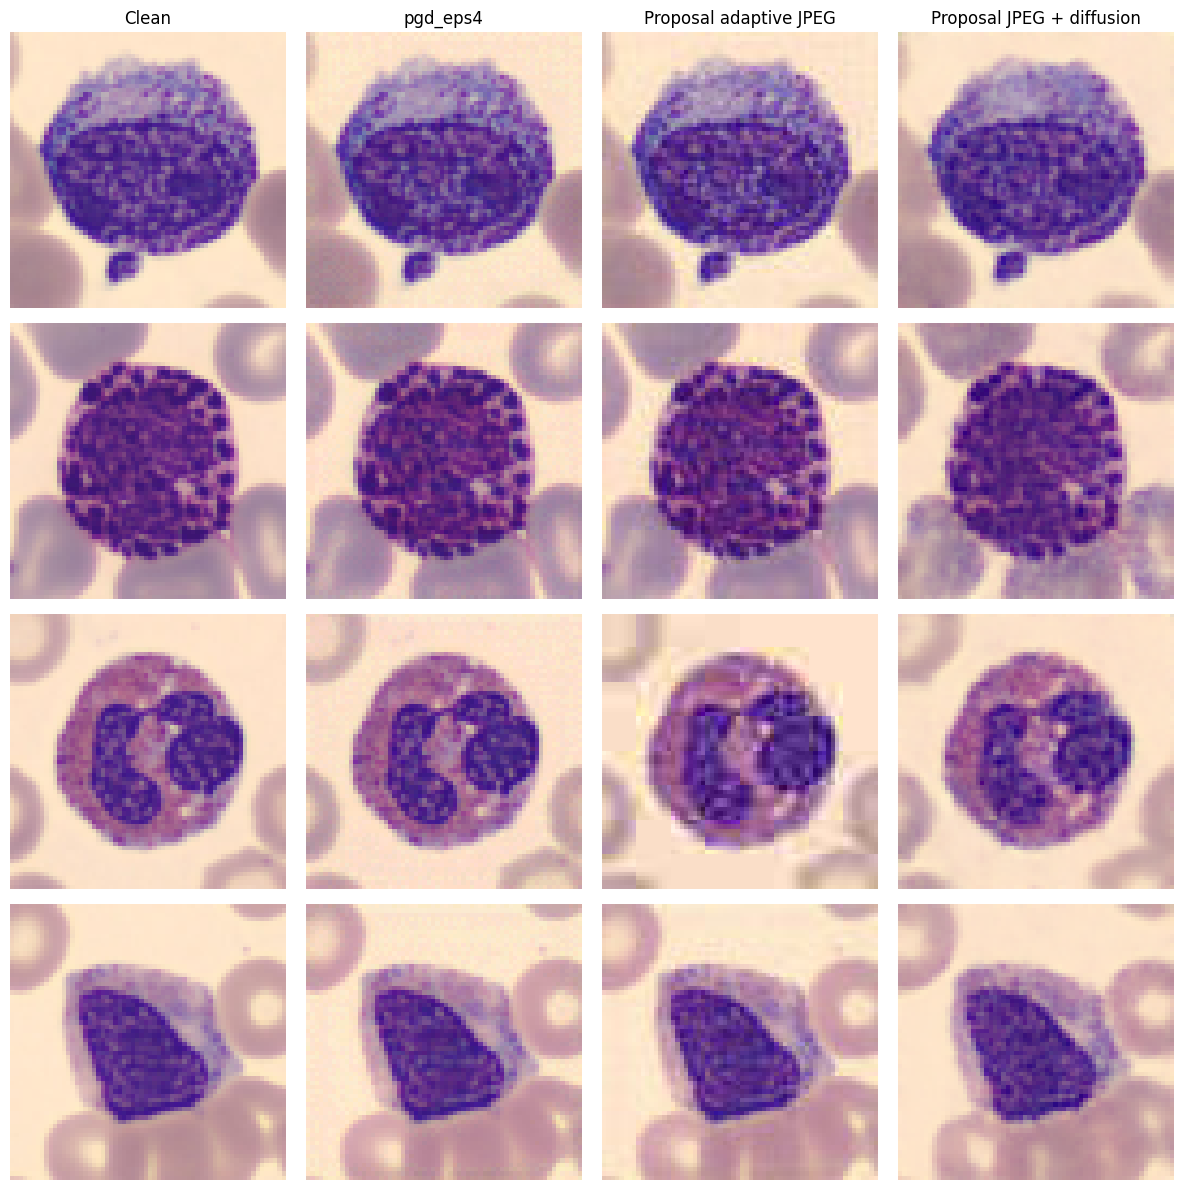

In [30]:
def show_stages(flag, architecture, spec, count=4):
    classifier = CLASSIFIERS[(flag, architecture)]
    defense = DEFENSES[(flag, architecture)]
    images, labels = next(iter(DATASETS[flag]["test"]))
    images = images[:count].to(DEVICE)
    labels = labels[:count]

    attacked = generate_attack(classifier, images, labels, spec)
    compressed, metadata = defense.select_proposal(attacked)
    shared_noise = fixed_noise_like(attacked, SEED + 800000)
    with torch.no_grad():
        purified, _ = defense.proposal_full(attacked, noise=shared_noise)

    stages = [
        ("Clean", images),
        (spec.name, attacked),
        ("Proposal adaptive JPEG", compressed),
        ("Proposal JPEG + diffusion", purified),
    ]
    figure, axes = plt.subplots(count, len(stages), figsize=(12, 3 * count))
    axes = np.asarray(axes).reshape(count, len(stages))
    for row in range(count):
        for column, (title, tensor) in enumerate(stages):
            axes[row, column].imshow(
                tensor[row].detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)
            )
            axes[row, column].axis("off")
            if row == 0:
                axes[row, column].set_title(title)
    plt.tight_layout()
    path = CFG.output_dir / "figures" / f"{flag}_{architecture}_{spec.name}_stages.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

show_stages("bloodmnist", "resnet18", ATTACK_SPECS[4])


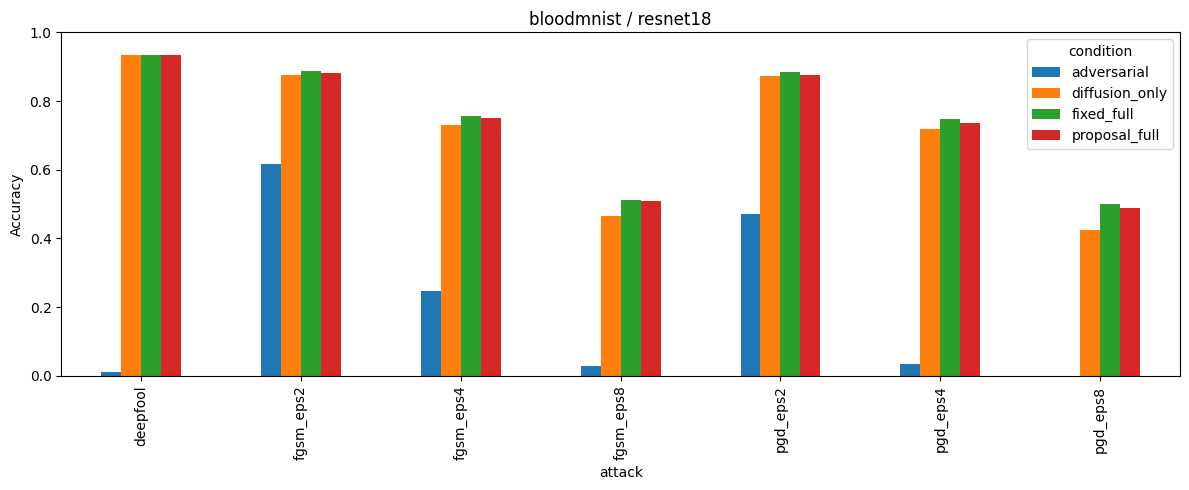

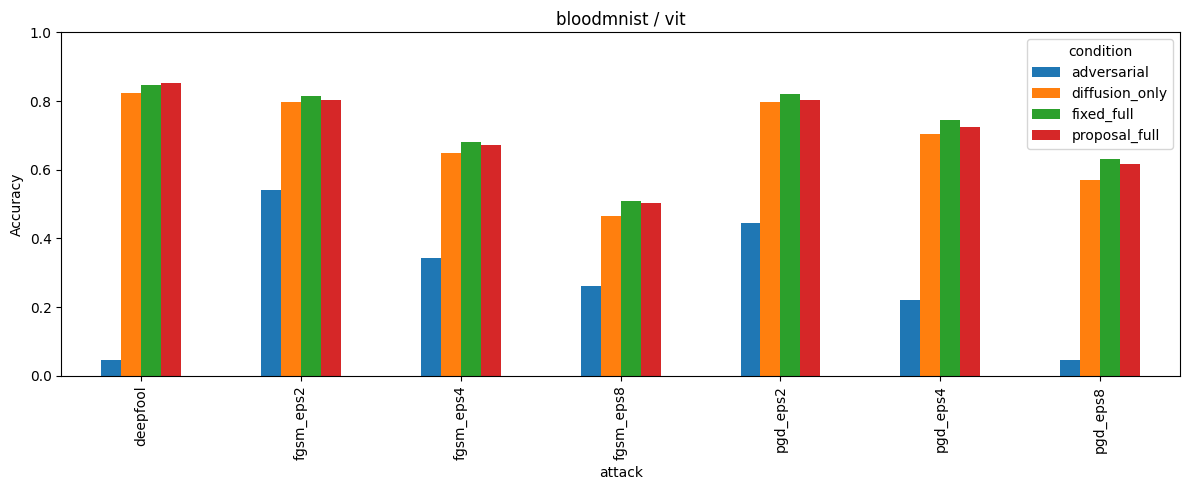

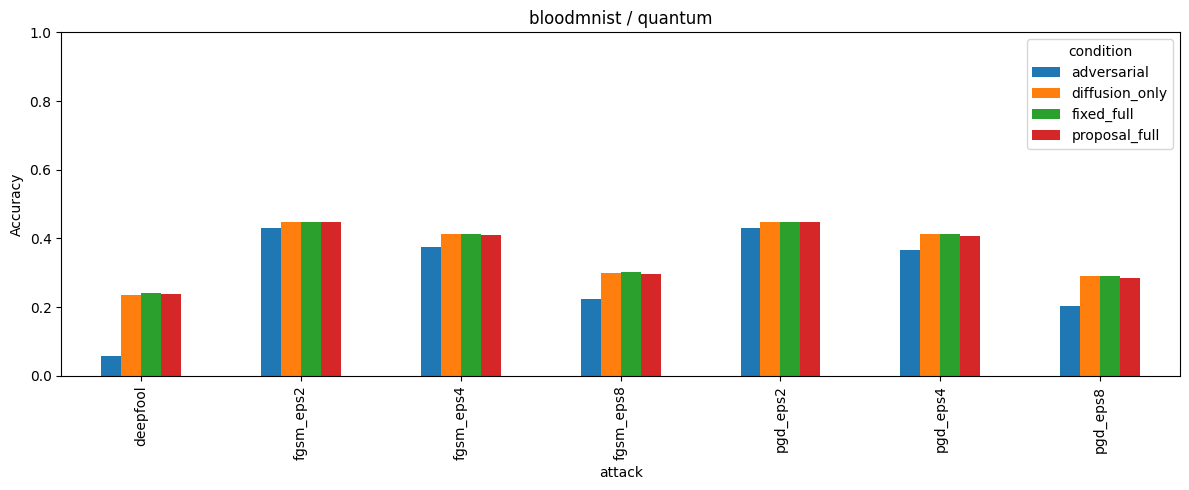

In [31]:
def plot_final_robust_accuracy(results, flag, architecture):
    subset = results[
        (results.dataset == flag)
        & (results.architecture == architecture)
        & results.condition.isin([
            "adversarial",
            "diffusion_only",
            "fixed_full",
            "proposal_full",
        ])
    ]
    pivot = subset.pivot_table(
        index="attack",
        columns="condition",
        values="accuracy",
        aggfunc="first",
    )
    axis = pivot.plot(kind="bar", figsize=(12, 5))
    axis.set_ylabel("Accuracy")
    axis.set_ylim(0, 1)
    axis.set_title(f"{flag} / {architecture}")
    plt.tight_layout()
    path = CFG.output_dir / "figures" / f"{flag}_{architecture}_final_robust_accuracy.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

for architecture in ARCHITECTURES:
    plot_final_robust_accuracy(BENCHMARK_RESULTS, "bloodmnist", architecture)


## 12. Final validation gates and evidence export

In [32]:
proposal_gate_images, _ = next(iter(DATASETS["bloodmnist"]["test"]))
proposal_gate_images = proposal_gate_images[:4].to(DEVICE)
proposal_gate_model = CLASSIFIERS[("bloodmnist", "resnet18")]
proposal_gate_defense = DEFENSES[("bloodmnist", "resnet18")]
with torch.no_grad():
    proposal_gate_selected, proposal_gate_meta = proposal_gate_defense.select_proposal(
        proposal_gate_images
    )

VALIDATION_GATES = {
    "bloodmnist_only": CFG.datasets == ("bloodmnist",),
    "all_three_architectures_enabled": set(ARCHITECTURES) == {"resnet18", "vit", "quantum"},
    "pixel_domain": bool(0 <= proposal_gate_images.min() <= proposal_gate_images.max() <= 1),
    "proposal_quality_set_exact": CFG.proposal_jpeg_qualities == (20, 40, 60, 80),
    "proposal_max_confidence_selector": bool(
        torch.equal(
            proposal_gate_meta["selected_index"],
            proposal_gate_meta["confidence"].argmax(dim=1),
        )
    ),
    "medical_diffusion_available": "bloodmnist" in DIFFUSION_MODELS,
    "paired_diffusion_noise_in_benchmark": "noise" in inspect.signature(condition_logits).parameters,
    "attack_sweep_has_fgsm_2_4_8": all(name in {s.name for s in ATTACK_SPECS} for name in ("fgsm_eps2", "fgsm_eps4", "fgsm_eps8")),
    "attack_sweep_has_pgd_2_4_8": all(name in {s.name for s in ATTACK_SPECS} for name in ("pgd_eps2", "pgd_eps4", "pgd_eps8")),
    "deepfool_reported_with_sample_cap": any(s.attack_type == "deepfool" and s.max_samples == FINAL_DEEPFOOL_SAMPLES for s in ATTACK_SPECS),
    "adaptive_bpda_eot_available": callable(adaptive_pgd_bpda_eot_final),
    "adaptive_sample_count_explicit": FINAL_ADAPTIVE_SAMPLES >= 1,
    "training_provenance_available": len(CLASSIFIER_PROVENANCE) == 3 and len(DIFFUSION_PROVENANCE) == 1,
    "quantum_model_is_hybrid_qnn": isinstance(CLASSIFIERS[("bloodmnist", "quantum")], HybridQuantumClassifier),
    "quantum_default_qubit_kept_on_cpu": all(
        parameter.device.type == "cpu"
        for parameter in CLASSIFIERS[
            ("bloodmnist", "quantum")
        ].quantum.parameters()
    ),
    "quantum_classical_blocks_on_main_device": (
        next(
            CLASSIFIERS[
                ("bloodmnist", "quantum")
            ].features.parameters()
        ).device == canonical_runtime_device(DEVICE)
        and next(
            CLASSIFIERS[
                ("bloodmnist", "quantum")
            ].head.parameters()
        ).device == canonical_runtime_device(DEVICE)
    ),
    "no_new_suspicion_policy_fitting": len(SUSPICION_FIT_RESULTS) == 0,
    "persistent_output_root": CFG.output_dir.exists(),
}

for name, passed in VALIDATION_GATES.items():
    print(f"{name:42s}: {'PASS' if passed else 'FAIL'}")

if not all(VALIDATION_GATES.values()):
    raise AssertionError([key for key, value in VALIDATION_GATES.items() if not value])

RESULT_STATUS = (
    "BLOODMNIST FINAL ARCHITECTURE EVALUATION — "
    "DEVELOPMENT-INFORMED; REVIEW BEFORE THESIS CLAIMS"
)
QUALITY_WARNINGS = [
    "BloodMNIST development/test observations influenced defense-family selection; this is not an untouched confirmatory dataset.",
    f"DeepFool is evaluated on {FINAL_DEEPFOOL_SAMPLES} deterministic test samples because of per-image gradient cost.",
    f"Adaptive BPDA/EOT is evaluated on {FINAL_ADAPTIVE_SAMPLES} deterministic test samples per architecture/defense because of reverse-diffusion cost.",
    "The quantum arm uses an analytic PennyLane simulator, not quantum hardware; do not claim quantum advantage without the resulting comparison.",
    "V11.4 keeps PennyLane default.qubit and VQC weights on CPU while the classical QNN feature extractor/head use the main PyTorch device.",
]
print(RESULT_STATUS)
for warning in QUALITY_WARNINGS:
    print("WARNING:", warning)


bloodmnist_only                           : PASS
all_three_architectures_enabled           : PASS
pixel_domain                              : PASS
proposal_quality_set_exact                : PASS
proposal_max_confidence_selector          : PASS
medical_diffusion_available               : PASS
paired_diffusion_noise_in_benchmark       : PASS
attack_sweep_has_fgsm_2_4_8               : PASS
attack_sweep_has_pgd_2_4_8                : PASS
deepfool_reported_with_sample_cap         : PASS
adaptive_bpda_eot_available               : PASS
adaptive_sample_count_explicit            : PASS
training_provenance_available             : PASS
quantum_model_is_hybrid_qnn               : PASS
quantum_default_qubit_kept_on_cpu         : PASS
quantum_classical_blocks_on_main_device   : PASS
no_new_suspicion_policy_fitting           : PASS
persistent_output_root                    : PASS
BLOODMNIST FINAL ARCHITECTURE EVALUATION — DEVELOPMENT-INFORMED; REVIEW BEFORE THESIS CLAIMS


In [33]:
result_dir = CFG.output_dir / "results"
result_dir.mkdir(parents=True, exist_ok=True)

CLEAN_RESULTS.to_csv(result_dir / "clean_metrics.csv", index=False)
CLEAN_DEFENSE_RESULTS.to_csv(result_dir / "clean_defense_metrics.csv", index=False)
BENCHMARK_RESULTS.to_csv(result_dir / "robustness_metrics.csv", index=False)
RAW_PREDICTIONS.to_csv(result_dir / "raw_predictions.csv", index=False)
ADAPTIVE_RESULTS.to_csv(result_dir / "adaptive_attack_metrics.csv", index=False)
PROFILE_RESULTS.to_csv(result_dir / "fidelity_runtime_metrics.csv", index=False)
CONFIDENCE_INTERVALS.to_csv(result_dir / "confidence_intervals.csv", index=False)
ARCHITECTURE_SUMMARY.to_csv(result_dir / "architecture_summary.csv", index=False)

classifier_history = []
for (flag, architecture), history in CLASSIFIER_HISTORIES.items():
    if len(history):
        table = history.copy()
        table.insert(0, "architecture", architecture)
        table.insert(0, "dataset", flag)
        classifier_history.append(table)
if classifier_history:
    pd.concat(classifier_history, ignore_index=True).to_csv(
        result_dir / "classifier_training_history.csv", index=False
    )

if len(DIFFUSION_HISTORIES["bloodmnist"]):
    table = DIFFUSION_HISTORIES["bloodmnist"].copy()
    table.insert(0, "dataset", "bloodmnist")
    table.to_csv(result_dir / "diffusion_training_history.csv", index=False)

manifest = {
    **asdict(CFG),
    "output_dir": str(CFG.output_dir),
    "architectures": ARCHITECTURES,
    "architecture_summary": ARCHITECTURE_SUMMARY.to_dict(orient="records"),
    "temperatures": {str(k): v for k, v in TEMPERATURES.items()},
    "result_status": RESULT_STATUS,
    "validation_gates": VALIDATION_GATES,
    "quality_warnings": QUALITY_WARNINGS,
    "method_revision": "v11_4_bloodmnist_final_validation_device_gate_fix",
    "evaluation_cache_enabled": True,
    "final_scope": {
        "dataset": "BloodMNIST",
        "other_datasets_intentionally_skipped": True,
        "full_clean_test": True,
        "full_fgsm_pgd_test": True,
        "deepfool_sample_cap": FINAL_DEEPFOOL_SAMPLES,
        "adaptive_bpda_eot_sample_cap": FINAL_ADAPTIVE_SAMPLES,
    },
    "defense_family_frozen": True,
    "final_primary_robustness_baseline": {
        "condition": "fixed_full",
        "description": "fixed JPEG Q60 + BloodMNIST-trained diffusion purification",
    },
    "faithful_proposal_method": {
        "condition": "proposal_full",
        "description": "max-softmax-confidence adaptive JPEG over Q={20,40,60,80} + BloodMNIST-trained diffusion",
        "test_labels_used_for_selection": False,
    },
    "retired_experimental_router": {
        "versions": "V7-V10",
        "used_in_final_primary_comparison": False,
        "reason": "development evidence did not support freezing it",
    },
    "attack_specs": [asdict(spec) for spec in ATTACK_SPECS],
    "adaptive_attack": {
        "epsilon": 4 / 255,
        "norm": "linf",
        "step_size": 1 / 255,
        "steps": CFG.adaptive_steps,
        "eot_samples": CFG.adaptive_eot_samples,
        "restarts": CFG.adaptive_restarts,
        "sample_count": FINAL_ADAPTIVE_SAMPLES,
        "conditions": ["fixed_full", "proposal_full"],
        "bpda": "identity BPDA through fixed/confidence-selected JPEG",
        "diffusion_gradient": "exact FP32 EOT gradient",
    },
    "classifier_training_provenance": {str(k): v for k, v in CLASSIFIER_PROVENANCE.items()},
    "diffusion_training_provenance": {str(k): v for k, v in DIFFUSION_PROVENANCE.items()},
    "quantum_arm": {
        "enabled": True,
        "type": "hybrid classical-quantum",
        "qubits": 4,
        "vqc_layers": 3,
        "embedding": "AngleEmbedding-Y",
        "ansatz": "StronglyEntanglingLayers",
        "measurements": "Pauli-Z expectation per qubit",
        "backend": "PennyLane default.qubit analytic simulator",
        "quantum_simulator_device": "cpu",
        "classical_feature_device": str(DEVICE),
        "classical_head_device": str(DEVICE),
        "mixed_device_autograd": True,
        "quantum_advantage_claim_allowed_without_results": False,
    },
}

with open(result_dir / "experiment_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2, default=str)

print("Evidence written to", result_dir)


Evidence written to /content/HybridDefense_22409007/hybrid_defense_artifacts_v11_blood_final/results


In [34]:
def sha256_file(path):
    digest=hashlib.sha256()
    with open(path,"rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): digest.update(block)
    return digest.hexdigest()
rows=[]
for path in sorted(CFG.output_dir.rglob("*")):
    if path.is_file(): rows.append({"path":str(path),"bytes":path.stat().st_size,"sha256":sha256_file(path)})
FILE_MANIFEST=pd.DataFrame(rows); FILE_MANIFEST.to_csv(result_dir/"file_manifest.csv",index=False); display(FILE_MANIFEST)

,path,bytes,sha256
0,/content/HybridDefense_22409007/hybrid_defense...,8200761,e98a76562ce60494a03fe8c68a48a9567cc3043c703ad9...
1,/content/HybridDefense_22409007/hybrid_defense...,28563,07ddea6bd000c3e187dffed418669934b35ee9a80943e4...
2,/content/HybridDefense_22409007/hybrid_defense...,44776779,c07b862fb4fed6aa93632ac8d1dbfbe63d3d175e43fa6a...
3,/content/HybridDefense_22409007/hybrid_defense...,3335767,72cbdcf4bdaa32a443f1a169fbb7ee3c22e495efa4433d...
4,/content/HybridDefense_22409007/hybrid_defense...,110318,c36d643f38311d05f0214d8a8ae8cd0fce7318116b2c32...
...,...,...,...
71,/content/HybridDefense_22409007/hybrid_defense...,861,2232311989af538a3d6acb20e58bba2d9263ce43146a7e...
72,/content/HybridDefense_22409007/hybrid_defense...,7905,e10bf7e83a0b48ded9ea950cfe8d34ebee51a3fea290eb...
73,/content/HybridDefense_22409007/hybrid_defense...,667,f1e3b67915d12e1fe09839a947513da5474d1199bebf58...
74,/content/HybridDefense_22409007/hybrid_defense...,29659439,0adea27bb193f2e7fc097fa00bdd907a388b7fd3fec119...


## V11 interpretation and freeze rule

V11 exists because V7 selected a mathematically valid but scientifically degenerate threshold that routed essentially every sample to the strong branch. V11 therefore adds a **validation-only non-degeneracy constraint**:

- clean false-positive/suspicious rate must be **≤ 25%** in development/full mode;
- attack detection rate across FGSM/PGD/DeepFool validation examples must be **≥ 75%**;
- the previous clean balanced-accuracy and per-attack regression constraints still apply.

The inference selector remains label-free. Labels are used only to evaluate candidate policies on the validation split.

Freeze only if the selected policy passes all validation constraints **and** the development audit shows that the light branch is actually used on a substantial fraction of clean examples. After that, stop BloodMNIST-driven method changes and move to PathMNIST and DermaMNIST under the frozen policy.

## 13. Final results ZIP and automatic download

This final cell runs only after all earlier experiment, validation, and export cells complete.


In [35]:
# FINAL CELL — package results and trigger download after successful completion
from datetime import datetime
from IPython.display import FileLink, display

if not all(VALIDATION_GATES.values()):
    raise RuntimeError("Results were not zipped because one or more validation gates failed.")

run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_stem = Path.cwd() / f"HybridDefense_BloodMNIST_Final_{run_stamp}"
staging_dir = Path.cwd() / f"_hybrid_defense_export_{run_stamp}"

if staging_dir.exists():
    shutil.rmtree(staging_dir)
staging_dir.mkdir(parents=True)

# Lightweight default: results, figures, and run metadata.
for folder_name in ("results", "figures"):
    source_folder = CFG.output_dir / folder_name
    if source_folder.exists():
        shutil.copytree(source_folder, staging_dir / folder_name)

# Checkpoints are optional because they can make browser downloads very large.
if ZIP_CHECKPOINTS:
    checkpoint_folder = CFG.output_dir / "checkpoints"
    if checkpoint_folder.exists():
        shutil.copytree(checkpoint_folder, staging_dir / "checkpoints")

archive_path = Path(
    shutil.make_archive(str(zip_stem), "zip", root_dir=staging_dir)
)
shutil.rmtree(staging_dir)

print(f"Results ZIP created: {archive_path.resolve()}")
print(f"Archive size: {archive_path.stat().st_size / (1024 ** 2):.2f} MB")

if AUTO_DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(str(archive_path))
    except ImportError:
        print("Automatic browser download is available in Google Colab.")
        print("For local Jupyter, use the download link below:")
        display(FileLink(str(archive_path)))
else:
    display(FileLink(str(archive_path)))


Results ZIP created: /content/HybridDefense_BloodMNIST_Final_20260812_233347.zip
Archive size: 15.79 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>